# STM VERIFICATION PER BREAST CANCER DATASET

# 1) MODELLO MLP

**SET-UP INIZIALE**

In [ ]:
import numpy as np
import pandas as pd
import json


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score, roc_auc_score
from collections import Counter

import os
import time

from google.colab import drive, files

import matplotlib.pyplot as plt




In [ ]:
data = load_breast_cancer()
X = data.data.astype(np.float64)          # matrice delle feature (n_samples, n_features)
y = data.target.astype(np.int64)          # vettore target (0 = malignant, 1 = benign)
feature_names = list(data.feature_names)  # nomi delle feature
target_names = list(data.target_names)    # ['malignant', 'benign']

print("Feature count:", X.shape[1])
print("Samples total:", X.shape[0])
print("Class labels:", target_names)
print("First 5 feature names:", feature_names[:5])
print("y distribution (raw counts):", {int(k): int(v) for k, v in pd.Series(y).value_counts().sort_index().items()})

Feature count: 30
Samples total: 569
Class labels: [np.str_('malignant'), np.str_('benign')]
First 5 feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
y distribution (raw counts): {0: 212, 1: 357}


- Ogni campione (una biopsia) ha 30 misure numeriche (es. dimensioni dei nuclei, uniformità, consistenza, ecc.).
- Il dataset contiene 569 casi clinici.
- Class labels: sono codificati in y come 0 = malignant (tumore maligno) e 1 = benign (tumore benigno).
- First 5 feature names: un’anteprima delle feature (mean radius, mean texture, mean perimeter...)
- Il dataset è sbilanciato: circa il 62% benigni e 38% maligni; lo split dovrà essere stratificato


**PRE-PROCESSING E SPLIT**

In [ ]:
# 1) Train/Test split (stratificato per preservare le proporzioni delle classi)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2) Standardizzazione: z = (x - mean_train) / std_train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit SOLO sul train
X_test_s  = scaler.transform(X_test)       # usa le stats del train

# 3) Diagnostica rapida
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("Class balance (train):", Counter(y_train))
print("Class balance (test) :", Counter(y_test))

# Verifica che in spazio standardizzato il train abbia media≈0 e std≈1
print("Train mean (std-space) ~ 0:", np.round(X_train_s.mean(axis=0)[:5], 3), "...")
print("Train std  (std-space) ~ 1:", np.round(X_train_s.std(axis=0)[:5], 3), "...")
print("Test mean (std-space)  (solo check, NON deve essere 0):", np.round(X_test_s.mean(axis=0)[:5], 3), "...")
print("Scaler first 3 means:", np.round(scaler.mean_[:3], 3))
print("Scaler first 3 scales:", np.round(scaler.scale_[:3], 3))


Shapes -> X_train: (455, 30) X_test: (114, 30)
Class balance (train): Counter({np.int64(1): 285, np.int64(0): 170})
Class balance (test) : Counter({np.int64(1): 72, np.int64(0): 42})
Train mean (std-space) ~ 0: [-0.  0. -0.  0.  0.] ...
Train std  (std-space) ~ 1: [1. 1. 1. 1. 1.] ...
Test mean (std-space)  (solo check, NON deve essere 0): [0.086 0.048 0.085 0.092 0.072] ...
Scaler first 3 means: [14.067 19.247 91.557]
Scaler first 3 scales: [ 3.496  4.4   24.123]


- Lo split 80/20 è stato fatto correttamente: 455 campioni nel train e 114 nel test, ciascuno con 30 feature.
- Class balance: le proporzioni sono preservate (stratified split): circa 62% benigni, 38% maligni, come nel dataset originale.
- Dopo la standardizzazione, i dati del train hanno media ≈ 0 e deviazione standard ≈ 1 per ciascuna feature
- Test mean: non avendo fittato lo scaler sul test, i valori standardizzati del test non devono avere media 0. Devono solo essere “compatibili” con lo scaling del train.
- Scaler first 3 means/scales: questi sono i valori di mean e std originali del train usati per standardizzare. Serviranno per la formalizzazione in logica SMT, perché definiscono la trasformazione z=(x-𝜇)/ 𝜎 (salvo
𝜇 e
𝜎
 come costanti nel JSON così Z3 potrà usare esattamente la stessa trasformazione dello sklearn).


**TRAINING: MLP 1HL**

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(12,),
    activation="relu",
    solver="adam",
    alpha=1e-4,             # lieve reg. L2
    learning_rate_init=1e-3,
    max_iter=800,           # budget ampio; early_stopping ferma prima
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=7
)

mlp.fit(X_train_s, y_train)

# Predizioni per stima accuracies
yhat_train = mlp.predict(X_train_s)
yhat_test  = mlp.predict(X_test_s)

print("Converged:", mlp.n_iter_ < mlp.max_iter)
print("Epochs used:", mlp.n_iter_)
print("Final loss:", getattr(mlp, "loss_", None))
print("Training accuracy:", round(accuracy_score(y_train, yhat_train), 4))
print("Test accuracy:", round(accuracy_score(y_test, yhat_test), 4))


Converged: True
Epochs used: 67
Final loss: 0.1726807531010336
Training accuracy: 0.9341
Test accuracy: 0.9035


- La convergenza è arrivata dopo 67 iterazioni/epoche
- Final loss: ~0.173. La funzione obiettivo (log-loss) finale è abbastanza bassa, segno che il modello ha imparato bene a discriminare benigno/maligno.
- Training accuracy: 0.9341 (~93.4%), ottima
- Test accuracy: 0.9035 (~90.4%). La generalizzazione è solida (gap train/test ≈ 3%).

Questo modello è abbastanza semplice ma anche sufficientemente accurato da essere realistico, e non troppo grande per la traduzione in SMT.

**METRICHE DETTAGLIATE**

In [ ]:
# Predizioni e probabilità sul TEST
y_pred = mlp.predict(X_test_s)
y_proba = mlp.predict_proba(X_test_s)[:, 1]

# 1) Classification report
print("=== Classification report (TEST) ===")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

# 2) Confusion Matrix con etichette
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
cm_df = pd.DataFrame(cm, index=[f"True {target_names[0]}", f"True {target_names[1]}"],
                        columns=[f"Pred {target_names[0]}", f"Pred {target_names[1]}"])
print("\n=== Confusion Matrix (TEST) ===")
print(cm_df)

# 3) Metriche globali
bal_acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"\nBalanced Accuracy (TEST): {bal_acc:.4f}")
print(f"ROC-AUC (TEST): {auc:.4f}")

# 4) Baseline naive per confronto (sempre predire classe maggioritaria)
majority_class = int(pd.Series(y_train).value_counts().idxmax())
baseline_acc = (y_test == majority_class).mean()
print(f"Baseline accuracy (sempre '{target_names[majority_class]}'): {baseline_acc:.4f}")


=== Classification report (TEST) ===
              precision    recall  f1-score   support

   malignant     0.8298    0.9286    0.8764        42
      benign     0.9552    0.8889    0.9209        72

    accuracy                         0.9035       114
   macro avg     0.8925    0.9087    0.8986       114
weighted avg     0.9090    0.9035    0.9045       114


=== Confusion Matrix (TEST) ===
                Pred malignant  Pred benign
True malignant              39            3
True benign                  8           64

Balanced Accuracy (TEST): 0.9087
ROC-AUC (TEST): 0.9735
Baseline accuracy (sempre 'benign'): 0.6316


Classification Report
1) Malignant (classe 0):
- Precision = 0.83: tra i casi che il modello ha previsto come maligni, l’83% erano davvero maligni.
- Recall = 0.93: il modello ha riconosciuto il 93% dei maligni presenti (pochi falsi negativi).
- F1 = 0.88: buon equilibrio fra precision e recall.
2) Benign (classe 1)
- Precision = 0.96: tra i casi previsti come benigni, il 96% erano corretti.
- Recall = 0.89: ha recuperato l’89% dei benigni, ma ha perso qualche caso (falsi negativi).
- F1 = 0.92: molto buono.

3) Accuracy complessiva = 0.9035 (90.4%)
4) Macro avg (media semplice fra classi) ≈ 0.90 → indica che le prestazioni sono equilibrate fra classi, nonostante lo sbilanciamento dei dati.

Confusion Matrix
- True malignant (42 casi) → il modello ne ha presi 39 giusti e sbagliati 3 (scambiati per benigni). Ciò significa che il modello è molto bravo a catturare i maligni (recall alto).

- True benign (72 casi) → il modello ne ha presi 64 giusti e sbagliati 8 (scambiati per maligni). Quindi il modello è “prudente” e classifica alcuni benigni come maligni (8 falsi positivi). Clinicamente è una scelta sensata: meglio un falso allarme che non perdere un tumore.

Metriche globali:
- Balanced Accuracy = 0.9087. Media di recall sulle due classi: corregge lo sbilanciamento del dataset: anche qui ~91%, conferma la solidità del modello.
- ROC-AUC = 0.9735. Altissimo: significa che il modello discrimina bene fra benigno/maligno su tutta la curva delle soglie, non solo a 0.5.
- Baseline accuracy = 0.632. Se prevedessi sempre “benigno” (classe maggioritaria), avrei solo il 63%. Quindi il modello porta un guadagno sostanziale.

**ARTEFATTO JSON**

Dopo aver addestrato il modello bisogna estrarre pesi/bias del modello per salvarle in un file JSON insieme alle statistiche dello StandardScaler.

Questo file JSON conterrà tutto ciò che serve per la traduzione in SMT: pesi, bias, info dello scaler (mean/scale), dimensioni dei layer e qualche metadato.

In [ ]:
# 1) Estrazione pesi e bias (sklearn: lista coefs_/intercepts_ per ogni layer)
W1, W2 = mlp.coefs_[0], mlp.coefs_[1]     # [input→hidden], [hidden→output]
b1, b2 = mlp.intercepts_[0], mlp.intercepts_[1]

# Verifica dimensioni
input_dim  = W1.shape[0]
hidden_dim = W1.shape[1]
output_dim = W2.shape[1]
print(f"Dims → input:{input_dim}, hidden:{hidden_dim}, output:{output_dim}")

# 2) Costruzione artefatto
artifact = {
    "feature_names": feature_names,
    "scaler": {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        # utili per definire domini di input nello spazio originale
        "train_min": X_train.min(axis=0).tolist(),
        "train_max": X_train.max(axis=0).tolist()
    },
    "architecture": {
        "hidden_sizes": [hidden_dim],
        "activation_hidden": "relu",
        "output_decision": "logit>=0"  # decisione binaria in SMT
    },
    "weights": {
        "W1": W1.tolist(), "b1": b1.tolist(),
        "W2": W2.tolist(), "b2": b2.tolist()
    },
    "metrics": {
        "train_accuracy": float((y_train == mlp.predict(X_train_s)).mean()),
        "test_accuracy":  float((y_test  == mlp.predict(X_test_s)).mean())
    },
    "notes": "Model trained with StandardScaler on train only; use z=(x-mu)/sigma in SMT."
}

# 3) Salvataggio su disco
json_path = "bcw_mlp_relu_logit.json"
with open(json_path, "w") as f:
    json.dump(artifact, f, indent=2)
print(f"Artefatto salvato → {json_path}")

# 4) Mini check coerenza logit vs sklearn su 3 campioni di test
def relu_np(v):
    return np.maximum(v, 0.0)

def model_logit_from_raw_x(x_raw):
    # Standardizza come in training
    z = (x_raw - scaler.mean_) / scaler.scale_
    h = relu_np(z @ W1 + b1)
    logit = float((h @ W2 + b2).ravel()[0])  # scalare
    return logit

ok_count = 0
for i in range(3):
    z = model_logit_from_raw_x(X_test[i])
    pred_logit = 1 if z >= 0.0 else 0
    pred_skl   = int(mlp.predict(X_test_s[[i]])[0])
    eq = (pred_logit == pred_skl)
    ok_count += int(eq)
    print(f"[Check {i}] logit={z:.4f} → pred_logit={pred_logit}, pred_sklearn={pred_skl}, match={eq}")

print(f"Coerenza (su 3 esempi): {ok_count}/3")




Dims → input:30, hidden:12, output:1
Artefatto salvato → bcw_mlp_relu_logit.json
[Check 0] logit=-5.8504 → pred_logit=0, pred_sklearn=0, match=True
[Check 1] logit=3.7751 → pred_logit=1, pred_sklearn=1, match=True
[Check 2] logit=-1.6861 → pred_logit=0, pred_sklearn=0, match=True
Coerenza (su 3 esempi): 3/3


- Dimensioni= input:30, hidden:12, output. Questa architettura è ottima per la traduzione SMT (pochi neuroni ⇒ poche disgiunzioni): 30 feature → 12 ReLU → 1 logit.
- Artefatto JSON salvato: è il file unico che verrà usato per generare la formula SMT. Contiene pesi, bias, scaler (mean/scale), ecc.
- Coerenza 3/3 sui mini-check: Il calcolo del logit fatto “a mano” coincide con la predizione di sklearn sui campioni testati: perfetta coerenza tra implementazione numerica e ciò che poi verrà codificato in SMT (dove userò la soglia logit ≥ 0)

In [ ]:
# Calcolo dei logit direttamente dal modello ricostruito
def compute_logit(X):
    # standardizzazione
    Z = (X - scaler.mean_) / scaler.scale_
    # hidden layer con ReLU
    H = np.maximum(Z @ W1 + b1, 0.0)
    # logit finale (uscita lineare)
    logit = (H @ W2 + b2).ravel()
    return logit

# Calcolo logit per train e test
logits_train = compute_logit(X_train)
logits_test = compute_logit(X_test)

# Predizione dalle regole sul logit (>=0 → classe 1, <0 → classe 0)
y_pred_train_logit = (logits_train >= 0).astype(int)
y_pred_test_logit  = (logits_test >= 0).astype(int)

# Accuracy
acc_train_logit = accuracy_score(y_train, y_pred_train_logit)
acc_test_logit  = accuracy_score(y_test, y_pred_test_logit)

print(f"Accuracy TRAIN (da logit) = {acc_train_logit:.4f}")
print(f"Accuracy TEST  (da logit) = {acc_test_logit:.4f}")


Accuracy TRAIN (da logit) = 0.9341
Accuracy TEST  (da logit) = 0.9035


Accuracy calcolata sui logit, identica! Perchè:

In scikit-learn la classificazione binaria si basa sulla sigmoide del logit:
sigma(z) = 1 / (1 + exp(-z))
con soglia 0.5 -> classe = 1 se sigma(z) >= 0.5, altrimenti 0.

Poiché la sigmoide è monotona crescente, vale:
sigma(z) >= 0.5 <=> z >= 0

Quindi la regola "logit >= 0" è esattamente equivalente a
"sigmoide(logit) >= 0.5".

Le predizioni ottenute con i logit coincidono con quelle di scikit-learn,
e di conseguenza le metriche (accuracy, precision, recall, ecc.) risultano identiche.


# 2) TRADUZIONE IN SMT

**Z3 SETUP E VARIABILI**
Installare/importare Z3
- Caricare il JSON del modello addestrato
- Creare variabili SMT per x (raw) e z (standardizzato)
- Aggiungere vincoli z_j = (x_j - mu_j)/sigma_j
- Preparare il solver Z3

In [ ]:
!pip -q install z3-solver

from z3 import *


# 1) Carica l'artefatto
with open("bcw_mlp_relu_logit.json", "r") as f:
    art = json.load(f)

mu    = np.array(art["scaler"]["mean"], dtype=float)
sigma = np.array(art["scaler"]["scale"], dtype=float)
W1    = np.array(art["weights"]["W1"], dtype=float)   # shape (30, 12)
b1    = np.array(art["weights"]["b1"], dtype=float)   # shape (12,)
W2    = np.array(art["weights"]["W2"], dtype=float)   # shape (12, 1)
b2    = float(np.array(art["weights"]["b2"], dtype=float).ravel()[0])

n_in  = W1.shape[0]
n_hid = W1.shape[1]

print("Loaded model dims:", n_in, "->", n_hid, "-> 1")

# 2) Variabili SMT: x (raw) e z (standardizzato)
x = [Real(f"x_{j}") for j in range(n_in)]
z = [Real(f"z_{j}") for j in range(n_in)]

# 3) Solver e vincoli di standardizzazione: z_j = (x_j - mu_j) / sigma_j
s = Solver()
for j in range(n_in):
    # z_j * sigma_j = x_j - mu_j  →  z_j = (x_j - mu_j) / sigma_j
    # (preferiamo la forma lineare evitando divisioni lato Z3)
    s.add( z[j] * sigma[j] == x[j] - mu[j] )

print("Added standardization constraints:", n_in)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.1/29.1 MB 43.3 MB/s eta 0:00:00
Loaded model dims: 30 -> 12 -> 1
Added standardization constraints: 30


- Le dimensioni del modello sono corrette: la rete ricostruita in Z3 è R^30⟶ReL^U12⟶logit^1
- I 30 vincoli di standardizzazione, uno per ogni feature, collegano le variabili nello spazio originale \(x_j\) con quelle standardizzate \(z_j\):

$$
z_j \cdot \sigma_j = x_j - \mu_j
\;\;\;\iff\;\;\;
z_j = \frac{x_j - \mu_j}{\sigma_j}
$$


- \(x_j\) = variabile raw, cioè il valore originale della feature.  
- \(\mu_j, \sigma_j\) = media e deviazione standard della feature calcolate sul training set (parametri dello `StandardScaler`).  
- \(z_j\) = variabile standardizzata che entra effettivamente nella rete.

In questo modo ho reso esplicito in SMT lo stesso preprocessing che fa scikit-learn: se impongo vincoli sulle feature originali \(x\), la rete userà automaticamente la versione standardizzata \(z\).



**RETE IN Z3 (ReLU + logit)**
- Creare le variabili SMT per il layer nascosto (pre-attivazioni a_i e post-attivazioni h_i).
- Aggiungere i vincoli della ReLU: h_i = max(0, a_i).
- Definire il logit di uscita come combinazione lineare dei neuroni nascosti.
- Nota: rimango in aritmetica reale con disgiunzioni (QF_LRA).

In [ ]:
from z3 import Real, Sum, And, Or, sat, unsat, unknown

# 1) Variabili SMT per layer nascosto
a = [Real(f"a_{i}") for i in range(n_hid)]  # pre-attivazioni (somma pesata + bias)
h = [Real(f"h_{i}") for i in range(n_hid)]  # post-attivazioni (uscite ReLU)

# 2) Vincoli pre-attivazioni: a_i = Σ_j (W1[j,i] * z_j) + b1[i]
for i in range(n_hid):
    lin = Sum(*[ z[j] * float(W1[j, i]) for j in range(n_in) ]) + float(b1[i])
    s.add( a[i] == lin )

# 3) Vincoli ReLU: h_i = max(0, a_i)
# Formalizzato come disgiunzione: (a_i <= 0 ∧ h_i = 0) ∨ (a_i >= 0 ∧ h_i = a_i)
for i in range(n_hid):
    s.add( Or( And(a[i] <= 0, h[i] == 0),
               And(a[i] >= 0, h[i] == a[i]) ) )

# 4) Logit di uscita: variabile SMT e vincolo lineare
logit = Real("logit")
lin_out = Sum(*[ h[i] * float(W2[i, 0]) for i in range(n_hid) ]) + float(b2)
s.add( logit == lin_out )

print("Added hidden layer constraints (a,h):", n_hid)
print("Added ReLU disjunctions:", n_hid)
print("Defined output variable: logit")


Added hidden layer constraints (a,h): 12
Added ReLU disjunctions: 12
Defined output variable: logit


Sono state introdotte le variabili per il layer nascosto:

- \(a_i\): pre-attivazione del neurone \(i\), cioè la somma pesata degli input più il bias.
- \(h_i\): uscita del neurone \(i\) dopo la funzione di attivazione ReLU.

Per ogni neurone nascosto vale:

$$
a_i = \sum_{j=1}^{30} W^{(1)}_{j,i} \cdot z_j + b^{(1)}_i
$$

La ReLU è formalizzata come vincolo disgiuntivo:

$$
h_i = \max(0, a_i) \;\;\;\Longleftrightarrow\;\;\;
\big( a_i \leq 0 \;\wedge\; h_i = 0 \big) \;\;\vee\;\; \big( a_i \geq 0 \;\wedge\; h_i = a_i \big)
$$

Infine, il logit di uscita è definito come:

$$
\text{logit} = \sum_{i=1}^{12} W^{(2)}_{i} \cdot h_i + b^{(2)}
$$

In questo modo la rete neurale è ora completamente ricostruita dentro Z3:
- ingresso \(x \to z\) (standardizzazione),
- hidden layer con ReLU,
- uscita come logit lineare.


**SANITY CHECK: SKLEARN vs Z3**
- Fissare un punto del test set: x_j = X_test[k, j]
- Verificare che logit_Z3 e pred_Z3 coincidano con sklearn
- Controllo extra: confrontare z_j dal modello Z3 con lo standardizzato sklearn
- Nota: y=0 (malignant), y=1 (benign)


In [ ]:
def z3_eval_as_float(model, expr):
    """Utility: valuta un'espressione Z3 come float Python."""
    val = model.eval(expr, model_completion=True)
    try:
        return float(val.as_decimal(20).replace("?", ""))  # per numeri razionali/algebrici
    except Exception:
        try:
            return float(str(val))
        except Exception:
            return None

def sanity_check_sample(k=0, show_dims=5):
    print(f"=== Sanity check su sample test index: {k} ===")
    # 1) Predizione sklearn
    skl_pred = int(mlp.predict(X_test_s[[k]])[0])
    skl_proba = float(mlp.predict_proba(X_test_s[[k]])[0, 1])  # proba classe 1 (benign)
    print(f"sklearn → pred={skl_pred} ({target_names[skl_pred]}), proba_benign={skl_proba:.4f}")

    # 2) Logit calcolato "a mano" (coerente con JSON)
    def relu_np(v): return np.maximum(v, 0.0)
    z_std = (X_test[k] - scaler.mean_) / scaler.scale_
    h_np = relu_np(z_std @ W1 + b1)
    logit_np = float((h_np @ W2 + b2).ravel()[0])
    pred_np = 1 if logit_np >= 0 else 0
    print(f"manual → logit={logit_np:.6f}, pred={pred_np} ({target_names[pred_np]})")

    # 3) Vincoli in Z3 per fissare x_j = X_test[k, j]
    s.push()
    for j in range(n_in):
        s.add(x[j] == float(X_test[k, j]))

    # 4) Check e lettura del modello
    res = s.check()
    print("Z3 check:", res)
    if res != sat:
        s.pop()
        return

    m = s.model()
    logit_z3 = z3_eval_as_float(m, logit)
    pred_z3 = 1 if logit_z3 is not None and logit_z3 >= 0.0 else 0
    print(f"Z3     → logit={logit_z3:.6f}, pred={pred_z3} ({target_names[pred_z3]})")

    # 5) Confronto alcuni z_j (Z3 vs sklearn standardizzato)
    z3_first = [z3_eval_as_float(m, z[j]) for j in range(show_dims)]
    skl_first = [float(z_std[j]) for j in range(show_dims)]
    print("\nPrimi z_j (Z3 vs sklearn):")
    for j in range(show_dims):
        print(f"z[{j}]: Z3={z3_first[j]:+.5f}  |  skl={skl_first[j]:+.5f}")

    s.pop()

# Eseguo il check su 2-3 indici per sicurezza
sanity_check_sample(k=0)
sanity_check_sample(k=1)
sanity_check_sample(k=2)


=== Sanity check su sample test index: 0 ===
sklearn → pred=0 (malignant), proba_benign=0.0029
manual → logit=-5.850385, pred=0 (malignant)
Z3 check: sat
Z3     → logit=-5.850385, pred=0 (malignant)

Primi z_j (Z3 vs sklearn):
z[0]: Z3=+1.56851  |  skl=+1.56851
z[1]: Z3=+2.16402  |  skl=+2.16402
z[2]: Z3=+1.74287  |  skl=+1.74287
z[3]: Z3=+1.62076  |  skl=+1.62076
z[4]: Z3=-0.26538  |  skl=-0.26538
=== Sanity check su sample test index: 1 ===
sklearn → pred=1 (benign), proba_benign=0.9776
manual → logit=3.775093, pred=1 (benign)
Z3 check: sat
Z3     → logit=3.775093, pred=1 (benign)

Primi z_j (Z3 vs sklearn):
z[0]: Z3=-0.84028  |  skl=-0.84028
z[1]: Z3=-0.59707  |  skl=-0.59707
z[2]: Z3=-0.87417  |  skl=-0.87417
z[3]: Z3=-0.77617  |  skl=-0.77617
z[4]: Z3=-1.09035  |  skl=-1.09035
=== Sanity check su sample test index: 2 ===
sklearn → pred=0 (malignant), proba_benign=0.1563
manual → logit=-1.686092, pred=0 (malignant)
Z3 check: sat
Z3     → logit=-1.686092, pred=0 (malignant)

Primi z

La rete è fedelmente ricostruita in Z3!
Per ciascun campione (k=0,1,2) la predizione sklearn coincide con:
- il logit calcolato a mano (usando i pesi/bias esportati) → stesso segno ⇒ stessa classe;
- la rete in Z3 → stesso valore di logit e stessa classe.

I primi 5 valori di z (standardizzati) combaciano tra Z3 e sklearn → i vincoli di standardizzazione z= (x-𝜇)/𝜎 sono corretti.



# 3) ROBUSTEZZA LOCALE

**ROBUSTEZZA LOCALE:  
L∞ in z-space (standardizzato)**

Questa cella definisce una funzione che, dato un indice
𝑘 del test set e un raggio
𝜀
𝑧, nega la proprietà (“esiste un punto nel box che cambia classe”) e interroga Z3.

Scopo:
- Dato un sample k, verifico se entro ||z - z0||_inf <= eps_z esiste un punto che cambia la classe rispetto a z0.
- Negazione della proprietà: esiste z nel box con pred(z) != pred(z0).

Esito:
- SAT   -> controesempio trovato (NON robusto)
- UNSAT -> nessun controesempio nel box (ROBUSTO entro eps_z)

Nota: lavoro in z-space; printo anche lo spostamento in x-space per interpretazione.

Tre istanze ROBUSTE entro 𝜀(𝑧) = 0.2
Risultati:
- Z3: unsat ⇒ non esiste alcuna perturbazione 𝑧
con
∥
𝑧
−
𝑧
0
∥
∞
≤
0.2
che cambi la classe.
- Dunque, per quei tre punti testati, la rete è localmente robusta nel box L∞ di raggio 0.2 in spazio standardizzato.

Funzione che calcola, dato un k, il massimo raggio di robustezza ε*_k:
- Monotonia: UNSAT(ε) ⇒ UNSAT(ε') per ε' < ε ; SAT(ε) ⇒ SAT(ε') per ε' > ε
- Strategia: trova un upper bound dove SAT (o raggiungi CAP), poi bisection nell’intervallo [lo (UNSAT), hi (SAT)] fino a tolleranza.
- Ritorna (eps_star, censored_flag, steps_log)

• censored_flag=True se nessun SAT fino a EPS_CAP (quindi ε*_k ≥ EPS_CAP)

In [ ]:
# Monta Google Drive e crea una cartella dedicata ai risultati
drive.mount('/content/drive')


SAVE_PATH = "/content/drive/MyDrive/robustezza/"
os.makedirs(SAVE_PATH, exist_ok=True)

print("Salverò i CSV in:", SAVE_PATH)


Mounted at /content/drive
Salverò i CSV in: /content/drive/MyDrive/robustezza/


In [ ]:
def check_local_robustness(k, eps_z, use_timeout=False, timeout_ms=0):
    # Classe/logit base (calcolato manualmente)
    z0 = (X_test[k] - scaler.mean_) / scaler.scale_
    h0 = np.maximum(z0 @ W1 + b1, 0.0)
    logit0 = float((h0 @ W2 + b2).ravel()[0])
    pred0 = 1 if logit0 >= 0.0 else 0

    # Vincoli box L_inf
    box = []
    for j in range(n_in):
        box.append(z[j] - float(z0[j]) <= eps_z)
        box.append(float(z0[j]) - z[j] <= eps_z)

    # Vincolo flip di classe
    flip = (logit < 0) if pred0 == 1 else (logit >= 0)

    # Risolvi con Z3
    s.push()
    if use_timeout and timeout_ms > 0:
        s.set("timeout", timeout_ms)
    s.add(*box)
    s.add(flip)
    res = s.check()

    if res == sat:
        m = s.model()
        # Ricostruisci input avversario per calcolare distanza
        z_adv = np.array([float(m.eval(z[j], model_completion=True).as_decimal(10).replace("?", ""))
                          for j in range(n_in)], dtype=float)
        x_adv = z_adv * scaler.scale_ + scaler.mean_
        dx_inf = float(np.max(np.abs(x_adv - X_test[k])))
        out = ("SAT", dx_inf)
    elif res == unsat:
        out = ("UNSAT", None)
    else:
        out = ("unknown", None)

    if use_timeout and timeout_ms > 0:
        s.set("timeout", 0)  # reset timeout
    s.pop()
    return out


In [ ]:
rows_local = []
for k in range(len(X_test)):
    t0 = time.perf_counter()
    status, dx = check_local_robustness(k, eps_z=0.05, use_timeout=False, timeout_ms=0)
    dt = time.perf_counter() - t0
    rows_local.append({
        "k": k,
        "eps": 0.05,
        "status": status,
        "dx_inf": dx,
        "time_s": dt
    })

df_time_local = pd.DataFrame(rows_local)
df_time_local.to_csv("timing_check_local.csv", index=False)

print(df_time_local.head())
print("\nTempo medio per check_local_robustness:", df_time_local["time_s"].mean(), "s")
print("Tempo totale:", df_time_local["time_s"].sum()/60, "min")


In [ ]:
files.download("timing_check_local.csv")

FileNotFoundError: Cannot find file: timing_check_local.csv

In [ ]:
def epsilon_star_for_k(k,
                       eps_init=0.05,
                       eps_cap=0.5,
                       tol=0.01,
                       use_timeout=False,
                       timeout_ms=0):
    steps = []

    # Primo probe
    status, _ = check_local_robustness(k, eps_init, use_timeout=use_timeout, timeout_ms=timeout_ms)
    steps.append(("probe", eps_init, status))

    if status == "unknown":
        return 0.0, False, steps
    if status == "SAT":
        lo, hi = 0.0, eps_init
    else:
        lo, hi = eps_init, eps_init
        while True:
            hi = min(2.0 * hi, eps_cap)
            status, _ = check_local_robustness(k, hi, use_timeout=use_timeout, timeout_ms=timeout_ms)
            steps.append(("expand", hi, status))
            if status in ("SAT", "unknown") or hi >= eps_cap:
                if hi >= eps_cap and status != "SAT":
                    return eps_cap, True, steps
                break

    # Bisection
    def is_robust(eps):
        st, _ = check_local_robustness(k, eps, use_timeout=use_timeout, timeout_ms=timeout_ms)
        steps.append(("bisect", eps, st))
        return (st == "UNSAT")

    st_lo, _ = check_local_robustness(k, lo, use_timeout=use_timeout, timeout_ms=timeout_ms)
    steps.append(("check_lo", lo, st_lo))
    if st_lo != "UNSAT":
        lo = 0.0

    while (hi - lo) > tol:
        mid = 0.5 * (lo + hi)
        if is_robust(mid):
            lo = mid
        else:
            hi = mid

    return round(lo, 4), False, steps


In [ ]:
# Misura tempi per epsilon_star_for_k su tutti i k del test
# Salvataggio progressivo su Drive con resume.


CSV_EPSSTAR = os.path.join(SAVE_PATH, "timing_epsilon_star_all.csv")

all_k = list(range(len(X_test)))
if os.path.exists(CSV_EPSSTAR):
    done = set(pd.read_csv(CSV_EPSSTAR)["k"].tolist())
    todo = [k for k in all_k if k not in done]
    print(f"Resume: trovate {len(done)} righe già salvate; restano {len(todo)}")
else:
    with open(CSV_EPSSTAR, "w") as f:
        f.write("k,eps_star,censored,time_s\n")
    todo = all_k
    print(f"Nessun file esistente: inizializzo, {len(todo)} campioni da processare.")

t0_all = time.perf_counter()
for i, k in enumerate(todo, 1):
    t0 = time.perf_counter()
    eps_star, censored, steps = epsilon_star_for_k(
        k,
        eps_init=0.05, eps_cap=0.4, tol=0.02,
        use_timeout=False, timeout_ms=0
    )
    dt = time.perf_counter() - t0

    with open(CSV_EPSSTAR, "a") as f:
        f.write(f"{k},{eps_star},{censored},{dt}\n")

    if i % 5 == 0 or i == len(todo):
        print(f"[{i}/{len(todo)}] k={k} -> eps*={eps_star} (cens={censored}) in {dt:.2f}s "
              f"(tot {(time.perf_counter()-t0_all)/60:.1f} min)")

print("Finito. File salvato:", CSV_EPSSTAR)


Nessun file esistente: inizializzo, 114 campioni da processare.
[5/114] k=4 -> eps*=0.4 (cens=True) in 15.78s (tot 11.1 min)
[10/114] k=9 -> eps*=0.4 (cens=True) in 20.85s (tot 54.9 min)
[15/114] k=14 -> eps*=0.1813 (cens=False) in 86.30s (tot 76.0 min)
[20/114] k=19 -> eps*=0.0875 (cens=False) in 89.32s (tot 100.3 min)
[25/114] k=24 -> eps*=0.3344 (cens=False) in 1075.29s (tot 134.1 min)
[30/114] k=29 -> eps*=0.4 (cens=True) in 239.61s (tot 182.5 min)
[35/114] k=34 -> eps*=0.4 (cens=True) in 282.30s (tot 220.5 min)
[40/114] k=39 -> eps*=0.4 (cens=True) in 89.99s (tot 259.1 min)
[45/114] k=44 -> eps*=0.2906 (cens=False) in 2452.97s (tot 318.7 min)
[50/114] k=49 -> eps*=0.4 (cens=True) in 122.63s (tot 329.7 min)
[55/114] k=54 -> eps*=0.025 (cens=False) in 8.40s (tot 373.5 min)
[60/114] k=59 -> eps*=0.025 (cens=False) in 6.91s (tot 437.2 min)
[65/114] k=64 -> eps*=0.4 (cens=True) in 91.47s (tot 531.6 min)
[70/114] k=69 -> eps*=0.0125 (cens=False) in 15.60s (tot 543.6 min)
[75/114] k=74 -

Funzione: espansione adattiva “senza cap” + bisezione

In [ ]:
def epsilon_star_for_k_unbounded(
    k,
    eps_start=0.4,          # parti da dove sai che era robusto
    growth=2.0,             # moltiplicatore di espansione
    tol=0.02,               # tolleranza finale sulla bisezione
    use_timeout=True,
    timeout_ms=5000,
    max_iters=20,           # guard-rail: espansioni massime
    z_guard_std=6.0,        # fermati se eps supera ~6 sigma (spazio z)
    verbose=True
):
    """
    Ricerca di epsilon* per il campione k:
      1) Conferma che eps_start sia UNSAT (robusto).
      2) Espansione moltiplicativa finche' trovi SAT/unknown (o tocchi i guard-rail).
      3) Bisezione in [lo, hi] fino a tol.
    Ritorna: (eps_star, censored_flag, details)
    - censored_flag=True se non si e' mai trovato SAT/unknown entro i guard-rail.
    """

    steps = []
    # Verifica punto di partenza
    st0, _ = check_local_robustness(k, eps_start, use_timeout=use_timeout, timeout_ms=timeout_ms)
    steps.append(("check_start", eps_start, st0))
    if st0 == "SAT":
        # sorprendente: a eps_start si flippa gia'
        # cerca tra [0, eps_start] con bisezione
        lo, hi = 0.0, eps_start
        # assicurati che lo sia UNSAT
        st_lo, _ = check_local_robustness(k, lo, use_timeout=use_timeout, timeout_ms=timeout_ms)
        steps.append(("check_lo", lo, st_lo))
        if st_lo != "UNSAT":
            lo = 0.0  # 0 e' per definizione robusto
        while (hi - lo) > tol:
            mid = 0.5 * (lo + hi)
            st_mid, _ = check_local_robustness(k, mid, use_timeout=use_timeout, timeout_ms=timeout_ms)
            steps.append(("bisect", mid, st_mid))
            if st_mid == "UNSAT":
                lo = mid
            else:
                hi = mid
        return round(lo, 4), False, steps

    # Se qui: st0 e' UNSAT o unknown (unknown lo trattiamo come non garantito)
    if st0 == "unknown":
        # non riusciamo a garantire neppure eps_start -> epsilon* ~ 0..eps_start
        # facciamo bisezione conservativa in [0, eps_start]
        lo, hi = 0.0, eps_start
        while (hi - lo) > tol:
            mid = 0.5 * (lo + hi)
            st_mid, _ = check_local_robustness(k, mid, use_timeout=use_timeout, timeout_ms=timeout_ms)
            steps.append(("bisect_unknown_start", mid, st_mid))
            if st_mid == "UNSAT":
                lo = mid
            else:
                hi = mid
        return round(lo, 4), False, steps

    # Espansione adattiva finche' trovi un hi non robusto
    lo = eps_start
    hi = eps_start
    it = 0
    reason = None
    while it < max_iters:
        hi = hi * growth
        it += 1
        # guard-rail per evitare esplorazioni prive di senso
        if hi > z_guard_std:
            reason = f"hit_guard_z>{z_guard_std}"
            break

        st_hi, _ = check_local_robustness(k, hi, use_timeout=use_timeout, timeout_ms=timeout_ms)
        steps.append(("expand", hi, st_hi))
        if st_hi in ("SAT", "unknown"):
            reason = "found_boundary"
            break
        else:
            lo = hi

    if verbose:
        print(f"[k={k}] expansion_end: lo={lo:.4f} hi={hi:.4f} iters={it} reason={reason}")

    if reason == "found_boundary":
        # Bisezione tra lo (UNSAT) e hi (SAT/unknown) fino a tol
        # per sicurezza, ricontrolla che lo sia UNSAT
        st_lo, _ = check_local_robustness(k, lo, use_timeout=use_timeout, timeout_ms=timeout_ms)
        steps.append(("check_lo_end", lo, st_lo))
        if st_lo != "UNSAT":
            lo = 0.0
        while (hi - lo) > tol:
            mid = 0.5 * (lo + hi)
            st_mid, _ = check_local_robustness(k, mid, use_timeout=use_timeout, timeout_ms=timeout_ms)
            steps.append(("bisect_final", mid, st_mid))
            if st_mid == "UNSAT":
                lo = mid
            else:
                hi = mid
        return round(lo, 4), False, steps

    # Se non abbiamo mai trovato un boundary (SAT/unknown) entro i guard-rail
    # allora restiamo "censurati" oltre l'ultimo lo.
    return round(lo, 4), True, steps


In [ ]:
# === Parametri e percorsi su Drive ===


SAVE_PATH = "/content/drive/MyDrive/robustezza/"
CSV_EPSSTAR = os.path.join(SAVE_PATH, "timing_epsilon_star_all.csv")   # risultati base
CSV_REFINE  = os.path.join(SAVE_PATH, "timing_refine_censored.csv")    # raffinamenti
CSV_MERGED  = os.path.join(SAVE_PATH, "epsilon_star_all_refined.csv")  # tabella finale aggiornata

assert os.path.exists(CSV_EPSSTAR), f"Non trovo {CSV_EPSSTAR}. Rilancia la cella che calcola epsilon_star_for_k."

# === 1) Carica risultati base e trova i censurati ===
df_eps = pd.read_csv(CSV_EPSSTAR)
censurati = df_eps.loc[df_eps["censored"] == True, "k"].astype(int).tolist()
print(f"Casi censurati trovati: {censurati if censurati else 'nessuno'}")

if not censurati:
    # Non c'è nulla da raffinare: copia semplicemente la tabella base in quella finale
    df_eps.to_csv(CSV_MERGED, index=False)
    print(f"Nessun caso censurato. Ho salvato direttamente -> {CSV_MERGED}")
else:
    # === 2) Resume raffinamento: se esiste un CSV parziale, evita di ripetere i già fatti ===
    done_refine = set()
    if os.path.exists(CSV_REFINE):
        df_done = pd.read_csv(CSV_REFINE)
        if "k" in df_done.columns:
            done_refine = set(df_done["k"].astype(int).tolist())

    todo = [k for k in censurati if k not in done_refine]
    print(f"Raffinamenti già esistenti: {len(done_refine)} | Da fare ora: {len(todo)}")

    # Inizializza CSV di raffinamento se non esiste
    if not os.path.exists(CSV_REFINE):
        with open(CSV_REFINE, "w") as g:
            g.write("k,eps_star_refined,censored_refined,time_s\n")

    # === 3) Raffina i rimasti (senza timeout) ===
    for i, k in enumerate(todo, 1):
        t0 = time.perf_counter()
        eps_star_new, cens_new, steps = epsilon_star_for_k_unbounded(
            k,
            eps_start=0.4, growth=2.0, tol=0.02,
            use_timeout=False, timeout_ms=0,    # niente timeout
            max_iters=20, z_guard_std=6.0,      # guard-rail
            verbose=True
        )
        dt = time.perf_counter() - t0

        with open(CSV_REFINE, "a") as g:
            g.write(f"{k},{eps_star_new},{cens_new},{dt}\n")

        print(f"[refine {i}/{len(todo)}] k={k} -> eps*={eps_star_new} (cens={cens_new}) in {dt:.2f}s")

    print(f"Raffinamento completato/sincronizzato -> {CSV_REFINE}")

    # === 4) Merge: sostituisci nei censurati i valori raffinati ===
    df_ref = pd.read_csv(CSV_REFINE)
    # Crea mappa k -> (eps_star_refined, censored_refined)
    map_ref = {int(r.k): (float(r.eps_star_refined), bool(r.censored_refined)) for _, r in df_ref.iterrows()}

    def replace_if_refined(row):
        k = int(row["k"])
        if k in map_ref:
            eps_new, cens_new = map_ref[k]
            row["eps_star"] = eps_new
            row["censored"] = cens_new
        return row

    df_final = df_eps.apply(replace_if_refined, axis=1)
    df_final.to_csv(CSV_MERGED, index=False)
    print(f"Tabella aggiornata (censurati sostituiti) -> {CSV_MERGED}")

    # === 5) Piccolo riepilogo finale ===
    print("\n--- Riepilogo robustezza (dopo raffinamento) ---")
    print(f"min eps*: {df_final['eps_star'].min():.4f} | max eps*: {df_final['eps_star'].max():.4f}")
    print(f"media: {df_final['eps_star'].mean():.4f} | mediana: {df_final['eps_star'].median():.4f}")
    print(f"censurati rimasti: {int(df_final['censored'].sum())}")


Casi censurati trovati: [0, 1, 2, 4, 6, 7, 8, 9, 12, 18, 22, 26, 29, 31, 34, 39, 40, 41, 43, 46, 49, 56, 58, 61, 62, 64, 70, 72, 73, 82, 85, 87, 92, 93, 94, 95, 98, 100, 101, 102, 103, 104, 105, 106, 107, 109, 111]
Raffinamenti già esistenti: 1 | Da fare ora: 46
[k=1] expansion_end: lo=0.4000 hi=0.8000 iters=1 reason=found_boundary
[refine 1/46] k=1 -> eps*=0.675 (cens=False) in 5061.97s
[k=2] expansion_end: lo=0.4000 hi=0.8000 iters=1 reason=found_boundary


**RISULTATI**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvato: /content/drive/MyDrive/robustezza/fractions_by_threshold_all.csv

Frazioni soglie fisse:
    type label  threshold  fraction_robust  count_robust  n_total
0  fixed  0.01       0.01         0.964912           110      114
1  fixed  0.05       0.05         0.885965           101      114
2  fixed  0.10       0.10         0.780702            89      114
3  fixed  0.20       0.20         0.684211            78      114
4  fixed  1.00       1.00         0.026316             3      114
5  fixed  1.50       1.50         0.008772             1      114

Frazioni soglie statistiche:
   type   label  threshold  fraction_robust  count_robust  n_total
0  stat      Q1   0.110900         0.745614            85      114
1  stat  Median   0.323400         0.508772            58      114
2  stat      Q3   0.496875         0.254386            29      114


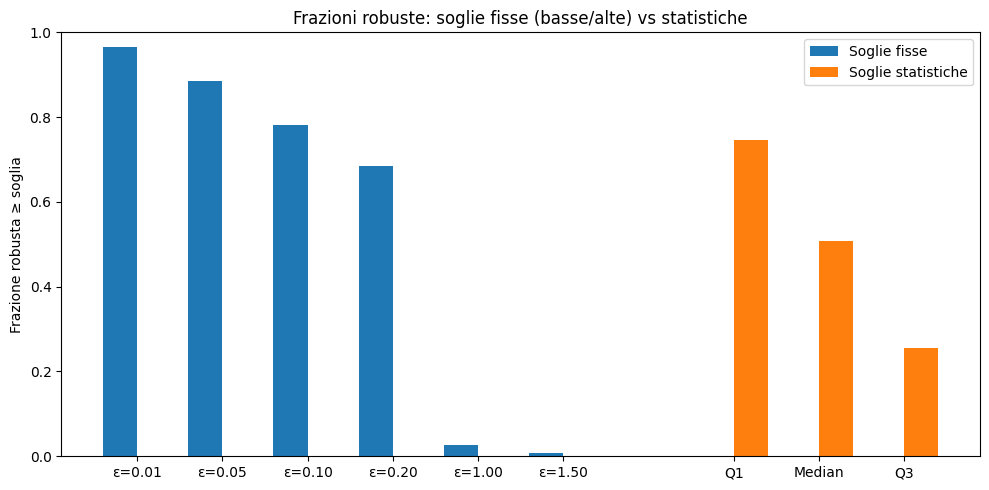

Salvato: /content/drive/MyDrive/robustezza/figs/fractions_bar_fixed_stat_high.png


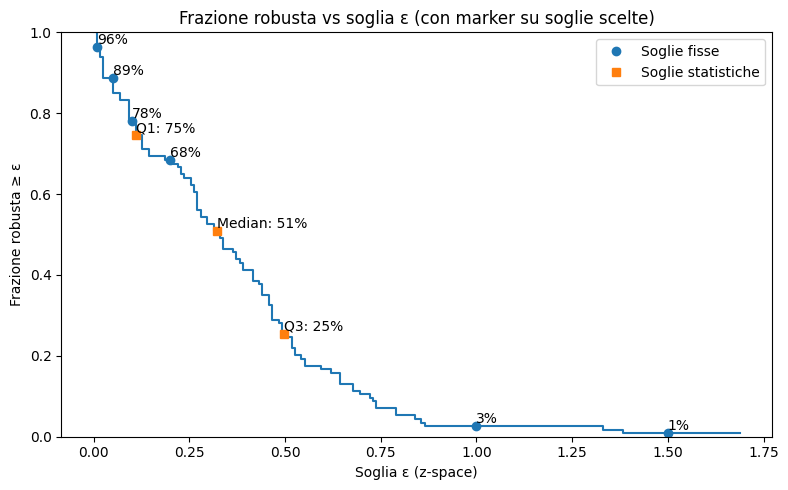

Salvato: /content/drive/MyDrive/robustezza/figs/fractions_step_with_high.png


In [ ]:
# === FRAZIONI ROBUSTE: SOGLIE FISSE + STATISTICHE + ALTE ===
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# --- Setup path ---
drive.mount('/content/drive')   # se già montato puoi commentare
SAVE_PATH = "/content/drive/MyDrive/robustezza/"
CSV_MERGED = os.path.join(SAVE_PATH, "epsilon_star_all_refined.csv")  # k, eps_star, censored
OUT = os.path.join(SAVE_PATH, "figs")
os.makedirs(OUT, exist_ok=True)

# --- Lettura dati ---
df = pd.read_csv(CSV_MERGED)
eps = df["eps_star"].astype(float).values
N = len(eps)

# --- Soglie fisse (basse + alte) ---
FIXED_THRESHOLDS = [0.01, 0.05, 0.10, 0.20, 1.0, 1.5]

rows_fixed = []
for thr in FIXED_THRESHOLDS:
    mask = (eps >= thr)
    rows_fixed.append({
        "type": "fixed",
        "label": f"{thr:.2f}",
        "threshold": float(thr),
        "fraction_robust": float(mask.mean()),
        "count_robust": int(mask.sum()),
        "n_total": int(N),
    })
df_fixed = pd.DataFrame(rows_fixed)

# --- Soglie statistiche (Q1, Mediana, Q3) ---
q1 = float(np.quantile(eps, 0.25))
med = float(np.median(eps))
q3 = float(np.quantile(eps, 0.75))
STAT_THRESHOLDS = [("Q1", q1), ("Median", med), ("Q3", q3)]

rows_stat = []
for name, thr in STAT_THRESHOLDS:
    mask = (eps >= thr)
    rows_stat.append({
        "type": "stat",
        "label": name,
        "threshold": float(thr),
        "fraction_robust": float(mask.mean()),
        "count_robust": int(mask.sum()),
        "n_total": int(N),
    })
df_stat = pd.DataFrame(rows_stat)

# --- CSV combinato ---
CSV_COMBO = os.path.join(SAVE_PATH, "fractions_by_threshold_all.csv")
pd.concat([df_fixed, df_stat], ignore_index=True).to_csv(CSV_COMBO, index=False)
print("Salvato:", CSV_COMBO)

# --- Stampe console ---
print("\nFrazioni soglie fisse:")
print(df_fixed)
print("\nFrazioni soglie statistiche:")
print(df_stat)

# === GRAFICI ===

# 1) Bar chart: frazioni (fisse e statistiche)
plt.figure(figsize=(10, 5))
x_fix = np.arange(len(df_fixed))
plt.bar(x_fix - 0.2, df_fixed["fraction_robust"].values,
        width=0.4, label="Soglie fisse", color="tab:blue")
x_stat = np.arange(len(df_stat)) + len(df_fixed) + 1
plt.bar(x_stat + 0.2, df_stat["fraction_robust"].values,
        width=0.4, label="Soglie statistiche", color="tab:orange")

xticks = list(x_fix) + list(x_stat)
xlabels = [f"ε={lab}" for lab in df_fixed["label"]] + [lab for lab in df_stat["label"]]
plt.xticks(xticks, xlabels, rotation=0)
plt.ylabel("Frazione robusta ≥ soglia")
plt.title("Frazioni robuste: soglie fisse (basse/alte) vs statistiche")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
bar_path = os.path.join(OUT, "fractions_bar_fixed_stat_high.png")
plt.savefig(bar_path, dpi=300)
plt.show()
print("Salvato:", bar_path)

# 2) Step plot con marker su tutte le soglie
x_grid = np.linspace(0, max(1e-12, eps.max()), 200)
S = [(eps >= t).mean() for t in x_grid]
plt.figure(figsize=(8, 5))
plt.step(x_grid, S, where='post', color="tab:blue")
plt.xlabel("Soglia ε (z-space)")
plt.ylabel("Frazione robusta ≥ ε")
plt.title("Frazione robusta vs soglia ε (con marker su soglie scelte)")

# marker soglie fisse
thr_x = np.array([t for t in FIXED_THRESHOLDS])
thr_y = np.array([(eps >= t).mean() for t in FIXED_THRESHOLDS])
plt.plot(thr_x, thr_y, 'o', color="tab:blue", label="Soglie fisse")

# marker soglie statistiche
thr_xs = np.array([q1, med, q3])
thr_ys = np.array([(eps >= t).mean() for t in thr_xs])
plt.plot(thr_xs, thr_ys, 's', color="tab:orange", label="Soglie statistiche")

for tx, ty in zip(thr_x, thr_y):
    plt.text(tx, ty, f"{ty:.0%}", ha='left', va='bottom')
for tx, ty, name in zip(thr_xs, thr_ys, ["Q1","Median","Q3"]):
    plt.text(tx, ty, f"{name}: {ty:.0%}", ha='left', va='bottom')

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
step_path = os.path.join(OUT, "fractions_step_with_high.png")
plt.savefig(step_path, dpi=300)
plt.show()
print("Salvato:", step_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


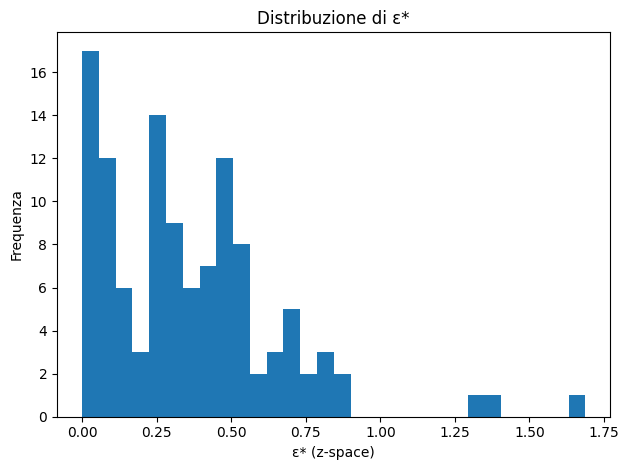

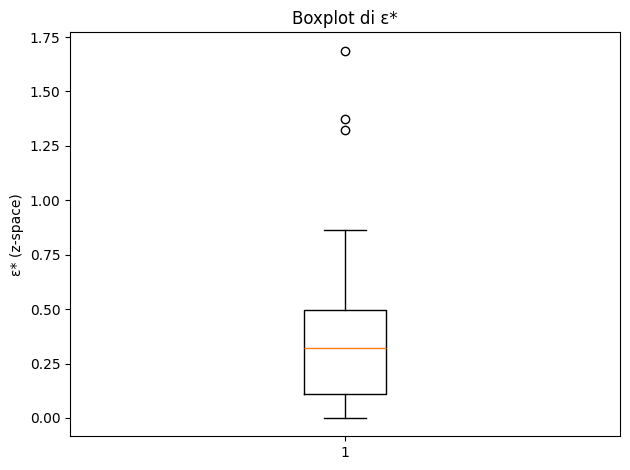

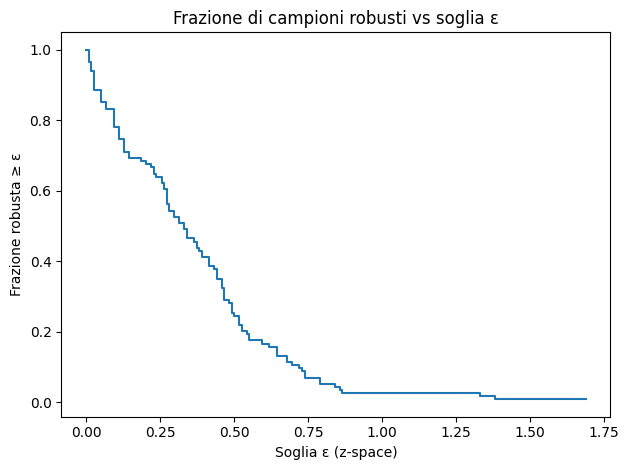

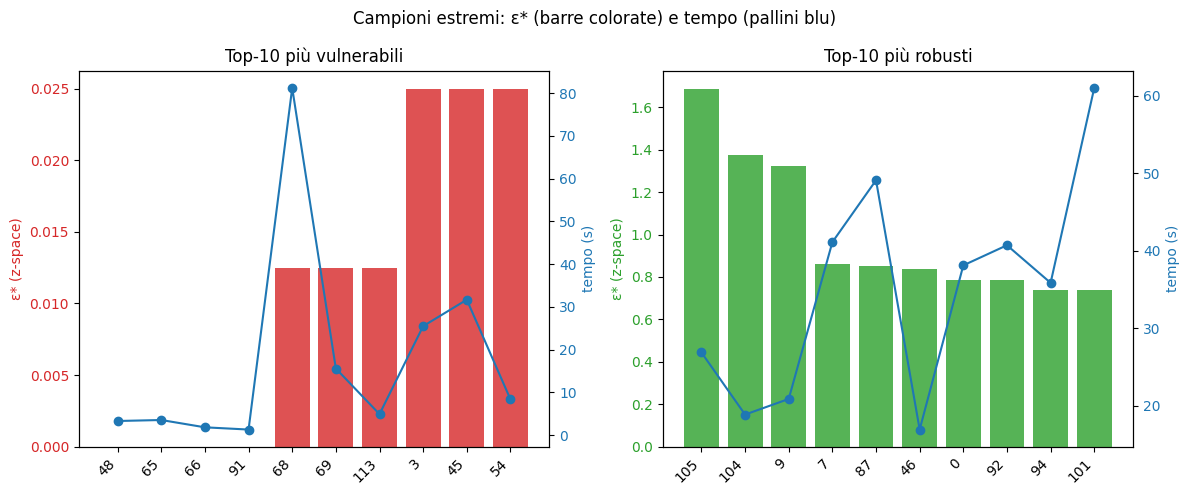

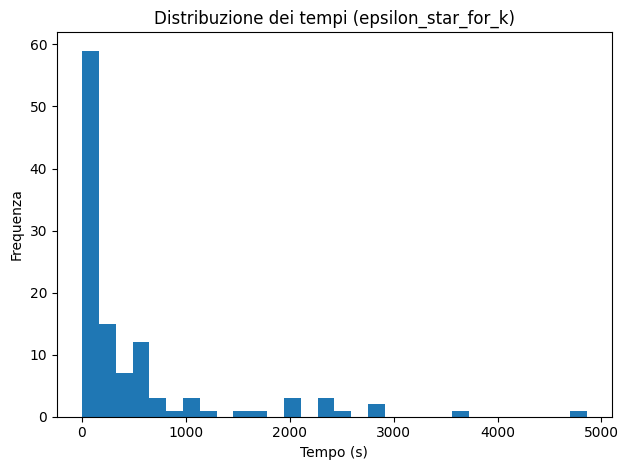

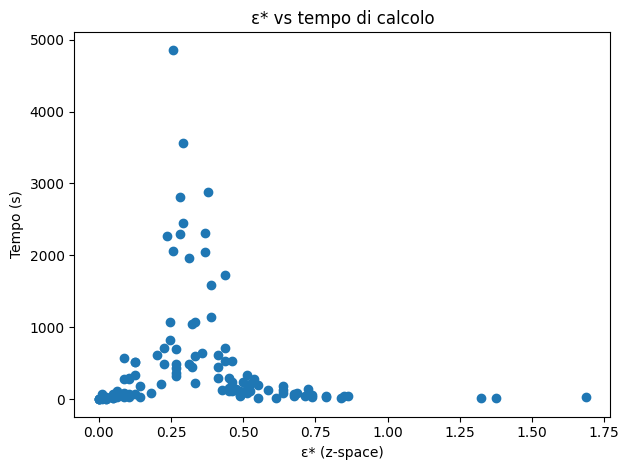

PNG salvati in: /content/drive/MyDrive/robustezza/figs


In [ ]:
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/robustezza/"
CSV_MERGED  = os.path.join(SAVE_PATH, "epsilon_star_all_refined.csv")   # finale (dopo refine)
CSV_EPSSTAR = os.path.join(SAVE_PATH, "timing_epsilon_star_all.csv")    # tempi base
OUT = os.path.join(SAVE_PATH, "figs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(CSV_MERGED)           # atteso: k, eps_star, censored (bool), [time_s opzionale]
df_time = pd.read_csv(CSV_EPSSTAR)     # atteso: k, eps_star, censored, time_s
dfm = pd.merge(df[['k','eps_star','censored']],
               df_time[['k','time_s']],
               on='k', how='left')

# ========== 1) ISTOGRAMMA ε* ==========
plt.figure()
plt.hist(df['eps_star'].values, bins=30)
plt.xlabel("ε* (z-space)")
plt.ylabel("Frequenza")
plt.title("Distribuzione di ε*")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "1_hist_eps_star.png"), dpi=300)
plt.show()

# ========== 2) BOXPLOT ε* ==========
plt.figure()
plt.boxplot(df['eps_star'].values, vert=True, showfliers=True)
plt.ylabel("ε* (z-space)")
plt.title("Boxplot di ε*")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "2_box_eps_star.png"), dpi=300)
plt.show()

# ========== 3) STEP PLOT: FRAZIONE ROBUSTA ≥ ε ==========
max_eps = df['eps_star'].max()
x_grid = np.linspace(0, max_eps if max_eps > 0 else 1e-6, 200)
S = [(df['eps_star'] >= t).mean() for t in x_grid]
plt.figure()
plt.step(x_grid, S, where='post')
plt.xlabel("Soglia ε (z-space)")
plt.ylabel("Frazione robusta ≥ ε")
plt.title("Frazione di campioni robusti vs soglia ε")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "3_step_frac_robust.png"), dpi=300)
plt.show()

# ========== 4) TOP-10 VULNERABILI & ROBUSTI — BARRE (ε*) + PALLINO (tempo) ==========

top_vuln = dfm.nsmallest(10, 'eps_star')[['k','eps_star','time_s']].copy()
top_rob  = dfm.nlargest(10, 'eps_star')[['k','eps_star','time_s']].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_bar_dot(ax, data, title, bar_color="tab:red"):
    x_labels = data['k'].astype(str).tolist()
    x = np.arange(len(data))
    # barre: ε*
    ax.bar(x, data['eps_star'], color=bar_color, alpha=0.8, label="ε*")
    ax.set_ylabel("ε* (z-space)", color=bar_color)
    ax.tick_params(axis='y', labelcolor=bar_color)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_title(title)
    # asse destro + pallini: tempo
    ax_t = ax.twinx()
    ax_t.plot(x, data['time_s'], 'o-', color="tab:blue", label="tempo (s)")
    ax_t.set_ylabel("tempo (s)", color="tab:blue")
    ax_t.tick_params(axis='y', labelcolor="tab:blue")

plot_bar_dot(axes[0], top_vuln, "Top-10 più vulnerabili", bar_color="tab:red")
plot_bar_dot(axes[1], top_rob,  "Top-10 più robusti",     bar_color="tab:green")

fig.suptitle("Campioni estremi: ε* (barre colorate) e tempo (pallini blu)")
fig.tight_layout()
plt.savefig(os.path.join(OUT, "4_top10_bar_plus_dot_colored.png"), dpi=300, bbox_inches='tight')
plt.show()


# ========== 5) ISTOGRAMMA TEMPI ==========
plt.figure()
plt.hist(dfm['time_s'].dropna().values, bins=30)
plt.xlabel("Tempo (s)")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei tempi (epsilon_star_for_k)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "5_hist_tempo.png"), dpi=300)
plt.show()

# ========== 6) SCATTER ε* VS TEMPO ==========
plt.figure()
plt.scatter(dfm['eps_star'], dfm['time_s'])
plt.xlabel("ε* (z-space)")
plt.ylabel("Tempo (s)")
plt.title("ε* vs tempo di calcolo")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "6_scatter_eps_vs_time.png"), dpi=300)
plt.show()

print("PNG salvati in:", OUT)


1- robustezza locale

Salvato: /content/drive/MyDrive/robustezza/figs_local/local_check_summary.csv
Salvato: /content/drive/MyDrive/robustezza/figs_local/local_check_status_counts.csv


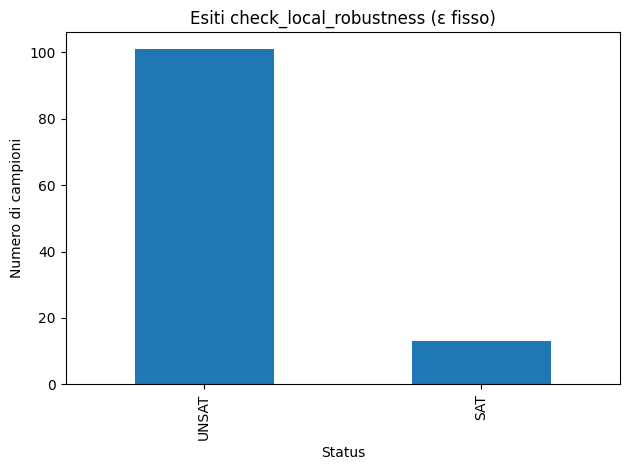

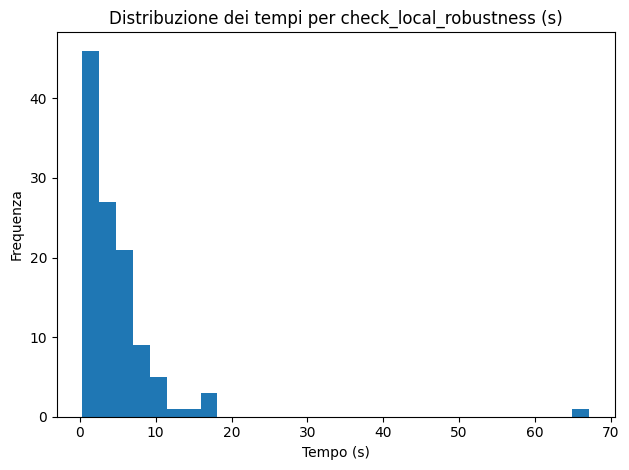

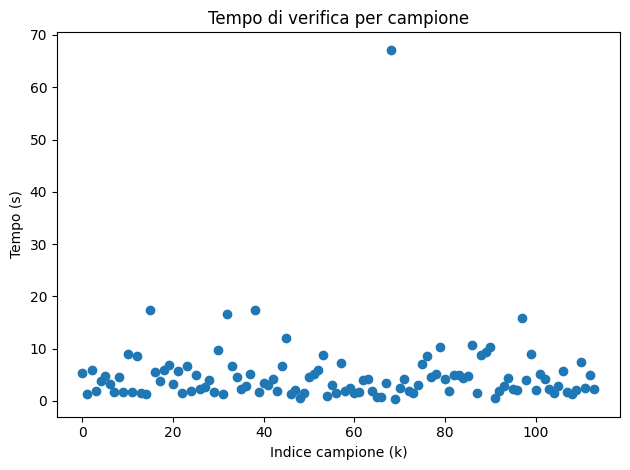

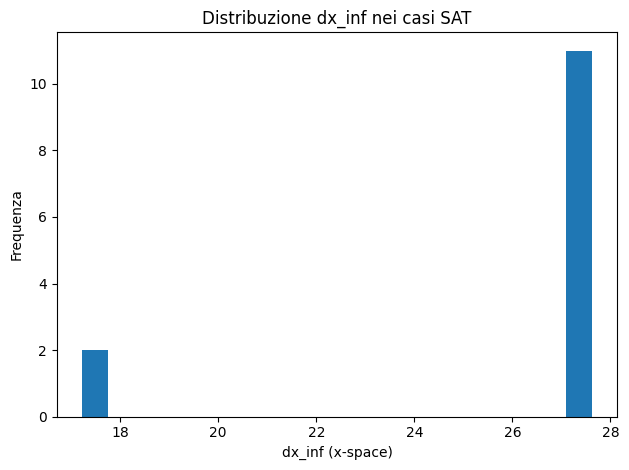


=== SINTESI ===
 n_total  n_UNSAT  n_SAT  n_UNKNOWN  time_mean_s  time_median_s  time_total_min  n_SAT_with_dx    dx_min    dx_max   dx_mean    dx_med
     114      101     13          0     4.969687       3.608966        9.442405             13 17.228265 27.615948 26.017843 27.615948

Breakdown esiti:
status  count  fraction
 UNSAT    101  0.885965
   SAT     13  0.114035

Figure salvate in: /content/drive/MyDrive/robustezza/figs_local


In [ ]:
# === ANALISI VERIFICA LOCALE (ε fisso) ===

csv_path = "/content/drive/MyDrive/robustezza/ROB LOCAL CON TEMPI.csv"
OUT = "/content/drive/MyDrive/robustezza/figs_local"
os.makedirs(OUT, exist_ok=True)

# --- Caricamento ---
df = pd.read_csv(csv_path)
# Normalizza intestazioni se necessario
df.columns = [c.strip().lower() for c in df.columns]

# --- Controlli colonne attese ---
expected = {"k","eps","status","dx_inf","time_s"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Mancano colonne nel CSV: {missing}. Colonne viste: {df.columns.tolist()}")

# --- Conversioni sicure ---
for col in ["eps","dx_inf","time_s"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# === 1) Conteggi esiti ===
counts = df["status"].value_counts().rename_axis("status").reset_index(name="count")
counts["fraction"] = counts["count"] / len(df)

# === 2) Tempi: medio/mediano/totale ===
time_mean   = float(df["time_s"].mean())
time_median = float(df["time_s"].median())
time_total_min = float(df["time_s"].sum() / 60.0)

# === 3) Statistiche dx_inf sui soli SAT ===
sat_dx = df.loc[df["status"]=="SAT", "dx_inf"].dropna()
dx_stats = {
    "n_SAT_with_dx": int(sat_dx.shape[0]),
    "dx_min":  float(sat_dx.min())  if len(sat_dx)>0 else np.nan,
    "dx_max":  float(sat_dx.max())  if len(sat_dx)>0 else np.nan,
    "dx_mean": float(sat_dx.mean()) if len(sat_dx)>0 else np.nan,
    "dx_med":  float(sat_dx.median()) if len(sat_dx)>0 else np.nan,
}

# === 4) Tabella riassuntiva (un’unica riga + breakdown esiti) ===
summary = {
    "n_total": len(df),
    "n_UNSAT": int((df["status"]=="UNSAT").sum()),
    "n_SAT":   int((df["status"]=="SAT").sum()),
    "n_UNKNOWN": int((df["status"]=="UNKNOWN").sum() if "UNKNOWN" in df["status"].unique() else 0),
    "time_mean_s": time_mean,
    "time_median_s": time_median,
    "time_total_min": time_total_min,
    **dx_stats
}
df_summary = pd.DataFrame([summary])

# Salvataggi CSV
summary_path = os.path.join(OUT, "local_check_summary.csv")
counts_path  = os.path.join(OUT, "local_check_status_counts.csv")
df_summary.to_csv(summary_path, index=False)
counts.to_csv(counts_path, index=False)
print("Salvato:", summary_path)
print("Salvato:", counts_path)

# === 5) Grafici ===

# (a) Bar esiti
plt.figure()
counts_plot = df["status"].value_counts()
counts_plot.plot(kind="bar")
plt.title("Esiti check_local_robustness (ε fisso)")
plt.xlabel("Status")
plt.ylabel("Numero di campioni")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "local_bar_status.png"), dpi=300)
plt.show()

# (b) Istogramma tempi
plt.figure()
plt.hist(df["time_s"].dropna(), bins=30)
plt.title("Distribuzione dei tempi per check_local_robustness (s)")
plt.xlabel("Tempo (s)")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "local_hist_time.png"), dpi=300)
plt.show()

# (c) Scatter tempo vs indice k
plt.figure()
plt.scatter(df["k"], df["time_s"])
plt.title("Tempo di verifica per campione")
plt.xlabel("Indice campione (k)")
plt.ylabel("Tempo (s)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "local_scatter_k_vs_time.png"), dpi=300)
plt.show()

# (d) Istogramma dx_inf (solo SAT)
if sat_dx.shape[0] > 0:
    plt.figure()
    plt.hist(sat_dx, bins=20)
    plt.title("Distribuzione dx_inf nei casi SAT")
    plt.xlabel("dx_inf (x-space)")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "local_hist_dx_inf_sat.png"), dpi=300)
    plt.show()
else:
    print("Nessun dx_inf disponibile per SAT: grafico (d) non generato.")

# --- Stampa sintesi in console ---
print("\n=== SINTESI ===")
print(df_summary.to_string(index=False))
print("\nBreakdown esiti:")
print(counts.to_string(index=False))
print(f"\nFigure salvate in: {OUT}")


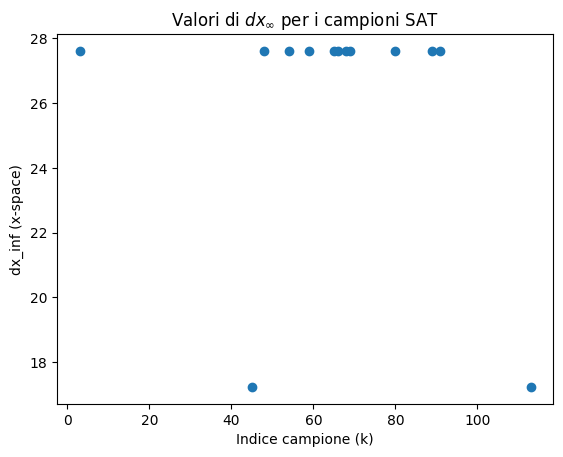

In [ ]:
sat_cases = df_local[df_local["status"]=="SAT"]
plt.scatter(sat_cases["k"], sat_cases["dx_inf"])
plt.title("Valori di $dx_\\infty$ per i campioni SAT")
plt.xlabel("Indice campione (k)")
plt.ylabel("dx_inf (x-space)")
plt.show()


2- epsilon star for k

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvato: /content/drive/MyDrive/robustezza/figs_results/epsilon_star_summary.csv
Salvato: /content/drive/MyDrive/robustezza/figs_results/epsilon_star_fractions.csv


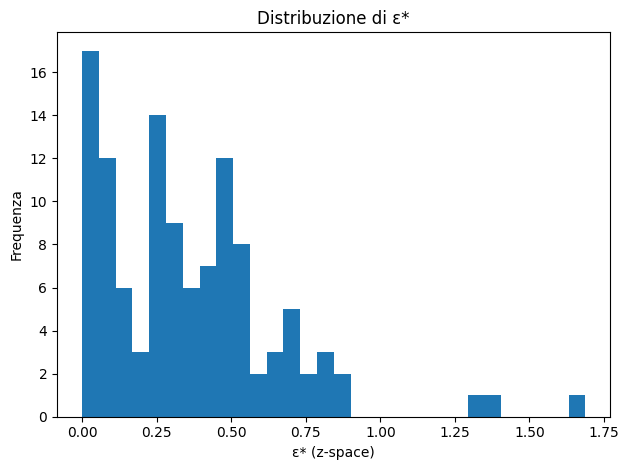

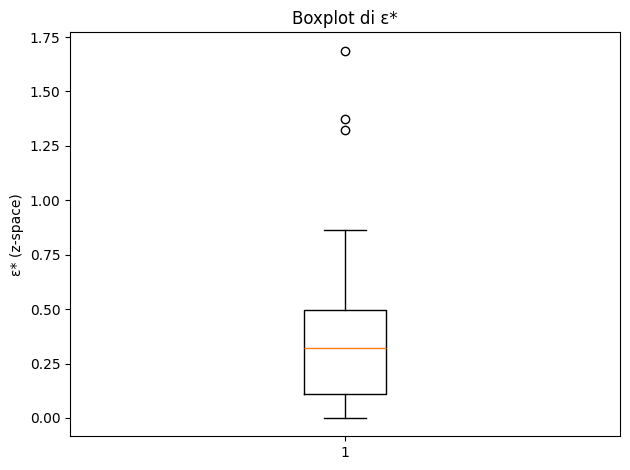

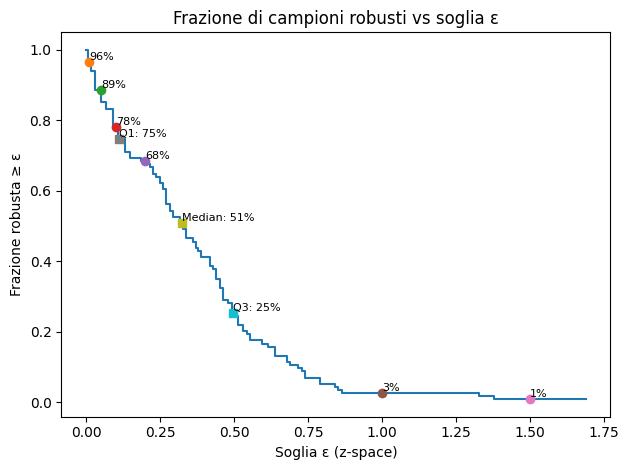

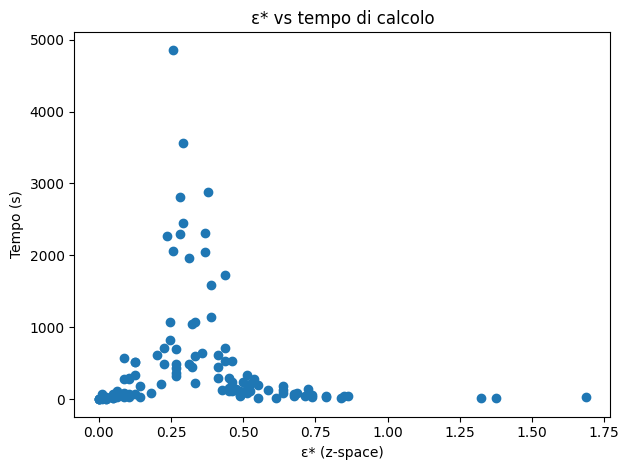


=== SINTESI DESCRITTIVA ===
 n_total  eps_star_min  eps_star_max  eps_star_mean  eps_star_median  eps_star_q1  eps_star_q3  eps_star_iqr  n_zero  time_mean_s  time_median_s  time_total_min
     114           0.0        1.6875       0.359317           0.3234       0.1109     0.496875      0.385975       4   495.751132     146.848173      941.927151

=== FRAZIONI ROBUSTE ===
 type  label  threshold  fraction_robust  count_robust  n_total
fixed   0.01   0.010000         0.964912           110      114
fixed   0.05   0.050000         0.885965           101      114
fixed   0.10   0.100000         0.780702            89      114
fixed   0.20   0.200000         0.684211            78      114
fixed   1.00   1.000000         0.026316             3      114
fixed   1.50   1.500000         0.008772             1      114
 stat     Q1   0.110900         0.745614            85      114
 stat Median   0.323400         0.508772            58      114
 stat     Q3   0.496875         0.254386       

In [ ]:
# === ANALISI ε*_k (epsilon_star) ===
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# --- PATH ---
drive.mount('/content/drive')  # se è già montato, puoi commentare
SAVE_PATH = "/content/drive/MyDrive/robustezza/"
CSV_MERGED = os.path.join(SAVE_PATH, "epsilon_star_all_refined.csv")  # <-- cambia se necessario
OUT = os.path.join(SAVE_PATH, "figs_results")
os.makedirs(OUT, exist_ok=True)

# --- Caricamento ---
df = pd.read_csv(CSV_MERGED)
df.columns = [c.strip().lower() for c in df.columns]
for c in ["eps_star","time_s"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

n = len(df)
assert {"k","eps_star","time_s"}.issubset(df.columns), f"Colonne viste: {df.columns.tolist()}"

# --- 1) STATISTICHE DESCRITTIVE ε* ---
q1 = float(df["eps_star"].quantile(0.25))
med = float(df["eps_star"].median())
q3 = float(df["eps_star"].quantile(0.75))
stats = {
    "n_total": n,
    "eps_star_min": float(df["eps_star"].min()),
    "eps_star_max": float(df["eps_star"].max()),
    "eps_star_mean": float(df["eps_star"].mean()),
    "eps_star_median": med,
    "eps_star_q1": q1,
    "eps_star_q3": q3,
    "eps_star_iqr": q3 - q1,
    "n_zero": int((df["eps_star"] == 0).sum()),
}

# --- 2) FRAZIONI ROBUSTE (soglie fisse + soglie statistiche) ---
fixed_thresholds = [0.01, 0.05, 0.10, 0.20, 1.00, 1.50]
stat_thresholds = [("Q1", q1), ("Median", med), ("Q3", q3)]

rows = []
for t in fixed_thresholds:
    frac = float((df["eps_star"] >= t).mean())
    rows.append({"type":"fixed","label":f"{t:.2f}","threshold":t,
                 "fraction_robust":frac, "count_robust": int(frac*n), "n_total": n})
for label, t in stat_thresholds:
    frac = float((df["eps_star"] >= t).mean())
    rows.append({"type":"stat","label":label,"threshold":float(t),
                 "fraction_robust":frac, "count_robust": int(frac*n), "n_total": n})

df_fractions = pd.DataFrame(rows)

# --- 3) TEMPI DI CALCOLO ---
time_stats = {
    "time_mean_s": float(df["time_s"].mean()),
    "time_median_s": float(df["time_s"].median()),
    "time_total_min": float(df["time_s"].sum() / 60.0),
}

# --- 4) SALVA TABELLE ---
summary = {**stats, **time_stats}
df_summary = pd.DataFrame([summary])
summary_path = os.path.join(OUT, "epsilon_star_summary.csv")
fractions_path = os.path.join(OUT, "epsilon_star_fractions.csv")
df_summary.to_csv(summary_path, index=False)
df_fractions.to_csv(fractions_path, index=False)
print("Salvato:", summary_path)
print("Salvato:", fractions_path)

# --- 5) GRAFICI ---

# (a) Istogramma ε*
plt.figure()
plt.hist(df["eps_star"].values, bins=30)
plt.xlabel("ε* (z-space)")
plt.ylabel("Frequenza")
plt.title("Distribuzione di ε*")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "hist_eps_star.png"), dpi=300)
plt.show()

# (b) Boxplot ε*
plt.figure()
plt.boxplot(df["eps_star"].values, vert=True, showfliers=True)
plt.ylabel("ε* (z-space)")
plt.title("Boxplot di ε*")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "box_eps_star.png"), dpi=300)
plt.show()

# (c) Step-plot: frazione robusta ≥ ε (con marker su soglie scelte)
x = np.sort(df["eps_star"].values)
# costruiamo CDF complementare S(t) = P(eps_star >= t)
t_grid = np.linspace(0, max(x) if len(x)>0 else 1e-6, 300)
S = [(df["eps_star"] >= t).mean() for t in t_grid]
plt.figure()
plt.step(t_grid, S, where="post")
# marker soglie fisse
for t in fixed_thresholds:
    frac = (df["eps_star"] >= t).mean()
    plt.plot([t], [frac], "o")
    plt.text(t, frac, f"{int(round(frac*100))}%", fontsize=8,
             ha="left", va="bottom")
# marker soglie statistiche
for label, t in stat_thresholds:
    frac = (df["eps_star"] >= t).mean()
    plt.plot([t], [frac], "s")
    plt.text(t, frac, f"{label}: {int(round(frac*100))}%", fontsize=8,
             ha="left", va="bottom")
plt.xlabel("Soglia ε (z-space)")
plt.ylabel("Frazione robusta ≥ ε")
plt.title("Frazione di campioni robusti vs soglia ε")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "step_frac_robust.png"), dpi=300)
plt.show()

# (d) Scatter ε* vs tempo
plt.figure()
plt.scatter(df["eps_star"], df["time_s"])
plt.xlabel("ε* (z-space)")
plt.ylabel("Tempo (s)")
plt.title("ε* vs tempo di calcolo")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "scatter_eps_vs_time.png"), dpi=300)
plt.show()

# --- Stampa sintesi in console ---
print("\n=== SINTESI DESCRITTIVA ===")
print(df_summary.to_string(index=False))
print("\n=== FRAZIONI ROBUSTE ===")
print(df_fractions.to_string(index=False))
print(f"\nFigure salvate in: {OUT}")


In [ ]:

feature_names = data.feature_names

X_test_df = pd.DataFrame(X_test, columns=feature_names)


X_test_df.to_csv("/content/drive/MyDrive/robustezza/X_test.csv", index=False)



In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# === INPUT ATTESI ===
# - df_eps: CSV con k, eps_star, censored, time_s (già caricato in precedenza)
# - X_test_df: DataFrame con le feature originali (non standardizzate) del test
# - y_test: array/Series con etichette binarie del test (0/1)
# - (opz.) clf: tuo MLP scikit-learn già addestrato (es. MLPClassifier) con predict_proba
# - (opz.) X_train_df, y_train: per il surrogato, se clf non c'è

# === PARAMETRI ===
TOP_K = 3
OUT_DIR = "/content/drive/MyDrive/robustezza/"

def pick_top_features(X_test_df, y_test, clf=None, X_train_df=None, y_train=None, k=3):
    """
    Restituisce una lista di k feature ordinate per importanza, usando:
    1) permutation importance sul modello 'clf' se disponibile
    2) altrimenti, RandomForest surrogata + permutation importance
    3) altrimenti, mutual information su (X_test, y_test)
    """
    # 1) Permutation importance sul modello vero (se disponibile)
    if clf is not None:
        try:
            scorer = make_scorer(roc_auc_score, needs_threshold=True)
            pi = permutation_importance(clf, X_test_df, y_test, scoring=scorer, n_repeats=10, random_state=0)
            importances = pd.Series(pi.importances_mean, index=X_test_df.columns)
            top = importances.sort_values(ascending=False).head(k).index.tolist()
            return top, ("permutation_importance", "clf")
        except Exception as e:
            print("Permutation importance su clf non riuscita:", e)

    # 2) Surrogato RandomForest se ho train (se clf non c'è o ha fallito)
    if (X_train_df is not None) and (y_train is not None):
        rf = RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            random_state=0,
            class_weight="balanced",
            n_jobs=-1
        )
        rf.fit(X_train_df, y_train)
        scorer = make_scorer(roc_auc_score, needs_threshold=True)
        pi = permutation_importance(rf, X_test_df, y_test, scoring=scorer, n_repeats=10, random_state=0)
        importances = pd.Series(pi.importances_mean, index=X_test_df.columns)
        top = importances.sort_values(ascending=False).head(k).index.tolist()
        return top, ("permutation_importance", "random_forest_surrogate")

    # 3) Fallback: Mutual Information su (X_test, y_test)
    try:
        mi = mutual_info_classif(X_test_df, y_test, random_state=0, discrete_features=False)
        importances = pd.Series(mi, index=X_test_df.columns)
        top = importances.sort_values(ascending=False).head(k).index.tolist()
        return top, ("mutual_information", "X_test_only")
    except Exception as e:
        raise RuntimeError("Impossibile calcolare importanze: mancano sia il modello sia i dati necessari.") from e

# === 1) Scegli in automatico le 3 feature migliori secondo il criterio disponibile ===
top_features, (method, source) = pick_top_features(
    X_test_df=X_test_df,
    y_test=y_test,
    clf=globals().get("clf", None),            # passa il tuo modello se è definito
    X_train_df=globals().get("X_train_df", None),
    y_train=globals().get("y_train", None),
    k=TOP_K
)
print(f"Top-{TOP_K} feature selezionate ({method} via {source}):", top_features)

# === 2) Costruisci le tabelle “campioni estremi” usando queste feature ===
# riallinea df_eps (assunto già caricato) e mergia con X_test_df
df_eps = df_eps.sort_values("k").reset_index(drop=True)
X_test_df_aligned = X_test_df.reset_index(drop=True)
df_full = pd.concat([df_eps, X_test_df_aligned], axis=1)

top_fragili = df_full.nsmallest(5, "eps_star")[["k","eps_star"] + top_features].round(4)
top_robusti = df_full.nlargest(5,  "eps_star")[["k","eps_star"] + top_features].round(4)

fragili_csv = OUT_DIR + "top5_fragili_auto.csv"
robusti_csv = OUT_DIR + "top5_robusti_auto.csv"
top_fragili.to_csv(fragili_csv, index=False)
top_robusti.to_csv(robusti_csv, index=False)
print("Salvati:", fragili_csv, "e", robusti_csv)



Top-3 feature selezionate (mutual_information via X_test_only): ['worst perimeter', 'worst radius', 'worst concave points']
Salvati: /content/drive/MyDrive/robustezza/top5_fragili_auto.csv e /content/drive/MyDrive/robustezza/top5_robusti_auto.csv
Blocco LaTeX salvato in: /content/drive/MyDrive/robustezza/tab_extreme_epsstar_auto.tex


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# --- Percorsi ---
drive.mount('/content/drive')  # se già montato, puoi commentare
X_path   = "/content/drive/MyDrive/robustezza/X_test.csv"
eps_path = "/content/drive/MyDrive/robustezza/epsilon_star_all_refined.csv"
OUT_DIR  = "/content/drive/MyDrive/robustezza/"

# --- Carica dati ---
X_test_df = pd.read_csv(X_path)
df_eps    = pd.read_csv(eps_path).sort_values("k").reset_index(drop=True)
X_test_df = X_test_df.reset_index(drop=True)

# --- Set di feature ---
clinical_features = ["mean radius", "mean area", "worst perimeter"]
auto_features     = ["worst perimeter", "worst radius", "worst concave points"]

preferred = clinical_features + auto_features
fallback_pool = [
    "worst area", "mean perimeter", "worst texture", "mean concavity",
    "mean compactness", "worst smoothness", "worst symmetry"
]

# Costruisci lista finale (6 feature distinte esistenti nel dataset)
features_final = []
seen = set()
for f in preferred + fallback_pool:
    if f in X_test_df.columns and f not in seen:
        features_final.append(f)
        seen.add(f)
    if len(features_final) == 6:
        break

print("Userò queste 6 feature:", features_final)

# --- Merge con eps_star ---
df_full = pd.concat([df_eps, X_test_df], axis=1)

# --- Estrai top-5 fragili e robusti ---
cols = ["k", "eps_star"] + features_final
top_fragili = df_full.nsmallest(5, "eps_star")[cols].copy()
top_robusti = df_full.nlargest(5,  "eps_star")[cols].copy()

# Arrotonda numeri
def _round_df(d):
    d2 = d.copy()
    d2["eps_star"] = pd.to_numeric(d2["eps_star"], errors="coerce").round(4)
    for f in features_final:
        if np.issubdtype(d2[f].dtype, np.number):
            d2[f] = d2[f].round(4)
    return d2

top_fragili = _round_df(top_fragili)
top_robusti = _round_df(top_robusti)

# --- Salva CSV ---
fragili_csv = OUT_DIR + "top5_fragili_6feat.csv"
robusti_csv = OUT_DIR + "top5_robusti_6feat.csv"
top_fragili.to_csv(fragili_csv, index=False)
top_robusti.to_csv(robusti_csv, index=False)

print("Salvati:", fragili_csv, "e", robusti_csv)

# --- Stampa per controllo rapido ---
print("\n--- TOP-5 FRAGILI (6 feat) ---")
print(top_fragili.to_string(index=False))
print("\n--- TOP-5 ROBUSTI (6 feat) ---")
print(top_robusti.to_string(index=False))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Userò queste 6 feature: ['mean radius', 'mean area', 'worst perimeter', 'worst radius', 'worst concave points', 'worst area']
Salvati: /content/drive/MyDrive/robustezza/top5_fragili_6feat.csv e /content/drive/MyDrive/robustezza/top5_robusti_6feat.csv

--- TOP-5 FRAGILI (6 feat) ---
 k  eps_star  mean radius  mean area  worst perimeter  worst radius  worst concave points  worst area
48    0.0000        16.17      788.5           113.10         16.97                0.1251       861.5
65    0.0000        14.60      664.7           102.20         15.79                0.1359       758.2
66    0.0000        14.96      687.3           109.10         16.25                0.1489       809.8
91    0.0000        12.75      493.8            93.63         14.45                0.0804       624.1
68    0.0125        12.88      493.1            99.31         15.05           

3- raffinati

=== RIEPILOGO ===
 n_cens_init  n_ref_rows  n_decensored  n_still_censored  eps_ref_min  eps_ref_max  eps_ref_mean  eps_ref_median  t_base_mean  t_base_median  t_ref_mean  t_ref_median  delta_t_mean  delta_t_median
          47          47            47                 0       0.4125       1.6875      0.625798           0.525   200.232259     122.626744 3160.710262   2544.035801   2960.478003     2292.444768
Salvato: /content/drive/MyDrive/robustezza/censurati_refine_summary.csv


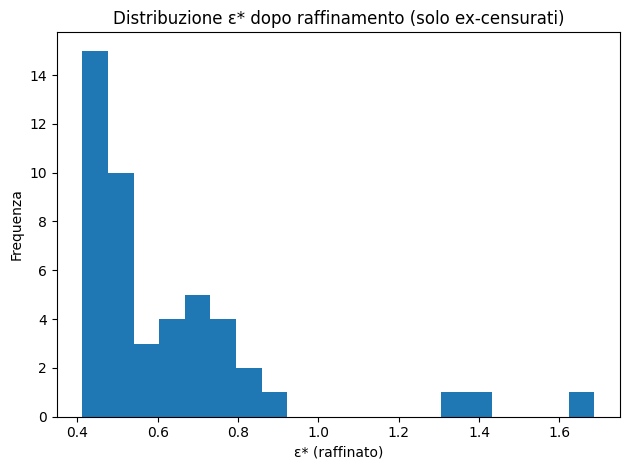

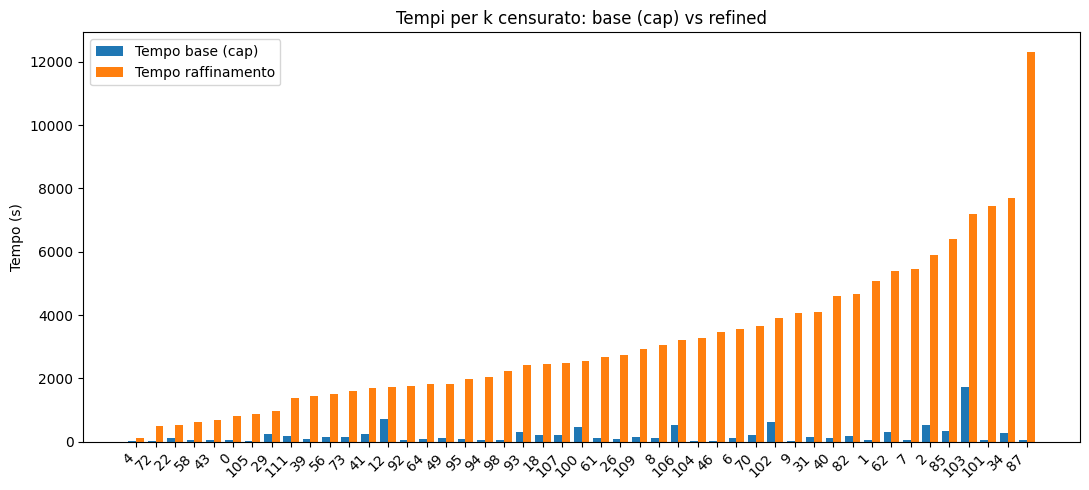

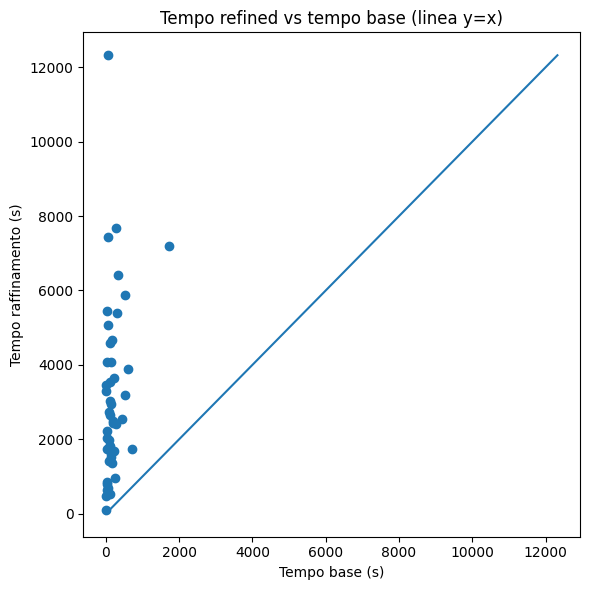

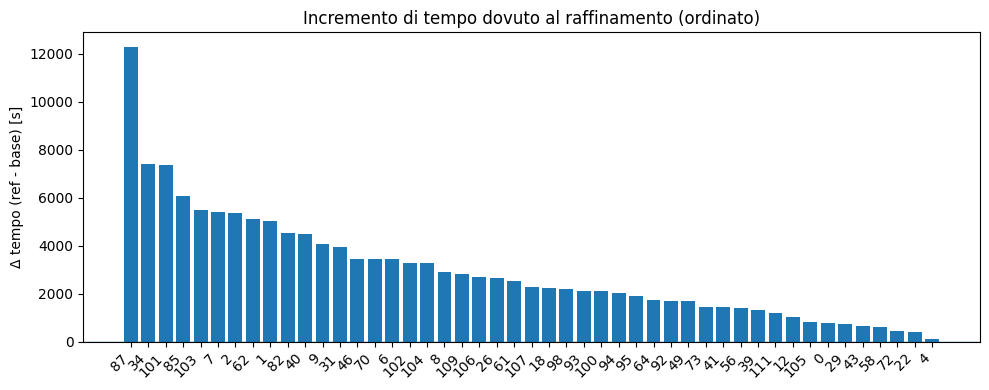

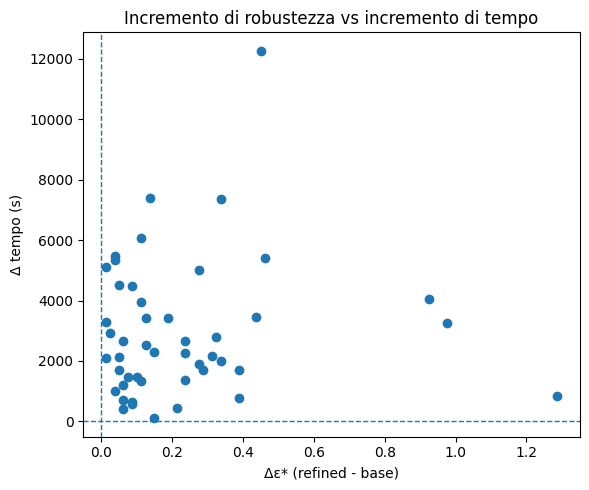


=== CORRELAZIONI ===
Correlazione tra ε* raffinato e tempo raffinamento: 0.026
Correlazione tra ε* raffinato e incremento di tempo (Δt): 0.072
Salvate in: /content/drive/MyDrive/robustezza/censurati_refine_correlations.txt
Tabella finale salvata: /content/drive/MyDrive/robustezza/censurati_refined_full.csv
Figure salvate in: /content/drive/MyDrive/robustezza/figs_censurati


In [ ]:
# === Raffinamento dei casi censurati: analisi completa ===

SAVE_PATH = "/content/drive/MyDrive/robustezza/"
CSV_BASE   = os.path.join(SAVE_PATH, "timing_epsilon_star_all.csv")   # k, eps_star, censored, time_s
CSV_REFINE = os.path.join(SAVE_PATH, "timing_refine_censored.csv")    # k, eps_star_refined, censored_refined, time_s
OUT_DIR    = os.path.join(SAVE_PATH, "figs_censurati")
os.makedirs(OUT_DIR, exist_ok=True)

# --- Caricamento ---
df_base = pd.read_csv(CSV_BASE)
df_ref  = pd.read_csv(CSV_REFINE)

# Tieni solo i k effettivamente censurati nella run base
cens_k = set(df_base.loc[df_base["censored"] == True, "k"].astype(int))
df_ref = df_ref[df_ref["k"].astype(int).isin(cens_k)].copy()

# Merge 1:1 su k
dfm = pd.merge(df_base, df_ref, on="k", how="inner", suffixes=("_base", "_ref"))
# Colonne standardizzate (già rinominate dallo suffix)
# dfm: ['k','eps_star','censored','time_s_base','eps_star_refined','censored_refined','time_s_ref']

# Derivate utili
dfm["delta_eps"] = dfm["eps_star_refined"] - dfm["eps_star"]
dfm["delta_t"]   = dfm["time_s_ref"]       - dfm["time_s_base"]

# --- RIEPILOGO E STATISTICHE ---
n_cens_init   = int(df_base["censored"].sum())
n_ref_rows    = len(dfm)
n_decensored  = int((dfm["censored_refined"] == False).sum()) if "censored_refined" in dfm else np.nan
n_still_cens  = int((dfm["censored_refined"] == True).sum())  if "censored_refined" in dfm else np.nan

stats = {
    "n_cens_init": n_cens_init,
    "n_ref_rows": n_ref_rows,
    "n_decensored": n_decensored,
    "n_still_censored": n_still_cens,
    "eps_ref_min": float(dfm["eps_star_refined"].min()) if n_ref_rows > 0 else np.nan,
    "eps_ref_max": float(dfm["eps_star_refined"].max()) if n_ref_rows > 0 else np.nan,
    "eps_ref_mean": float(dfm["eps_star_refined"].mean()) if n_ref_rows > 0 else np.nan,
    "eps_ref_median": float(dfm["eps_star_refined"].median()) if n_ref_rows > 0 else np.nan,
    "t_base_mean": float(dfm["time_s_base"].mean()) if n_ref_rows > 0 else np.nan,
    "t_base_median": float(dfm["time_s_base"].median()) if n_ref_rows > 0 else np.nan,
    "t_ref_mean": float(dfm["time_s_ref"].mean()) if n_ref_rows > 0 else np.nan,
    "t_ref_median": float(dfm["time_s_ref"].median()) if n_ref_rows > 0 else np.nan,
    "delta_t_mean": float(dfm["delta_t"].mean()) if n_ref_rows > 0 else np.nan,
    "delta_t_median": float(dfm["delta_t"].median()) if n_ref_rows > 0 else np.nan,
}
summary_df = pd.DataFrame([stats])
summary_csv = os.path.join(SAVE_PATH, "censurati_refine_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("=== RIEPILOGO ===")
print(summary_df.to_string(index=False))
print("Salvato:", summary_csv)

# --- 1) Istogramma ε* raffinati (solo ex-censurati) ---
if n_ref_rows > 0:
    plt.figure()
    plt.hist(dfm["eps_star_refined"].values, bins=20)
    plt.xlabel("ε* (raffinato)")
    plt.ylabel("Frequenza")
    plt.title("Distribuzione ε* dopo raffinamento (solo ex-censurati)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "hist_eps_refined.png"), dpi=300)
    plt.show()

# --- 2) Confronto tempi base vs refined (barre affiancate) ---
if n_ref_rows > 0:
    df_plot = dfm.sort_values("time_s_ref").reset_index(drop=True)
    x = np.arange(len(df_plot))
    plt.figure(figsize=(11,5))
    plt.bar(x - 0.2, df_plot["time_s_base"], width=0.4, label="Tempo base (cap)")
    plt.bar(x + 0.2, df_plot["time_s_ref"],  width=0.4, label="Tempo raffinamento")
    plt.xticks(x, df_plot["k"].astype(str), rotation=45, ha="right")
    plt.ylabel("Tempo (s)")
    plt.title("Tempi per k censurato: base (cap) vs refined")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "tempo_base_vs_refined_bars.png"), dpi=300)
    plt.show()

# --- 3) Scatter: tempo refined vs tempo base (+ linea y=x) ---
if n_ref_rows > 0:
    plt.figure(figsize=(6,6))
    plt.scatter(dfm["time_s_base"], dfm["time_s_ref"])
    max_t = float(max(dfm["time_s_base"].max(), dfm["time_s_ref"].max()))
    plt.plot([0, max_t], [0, max_t])
    plt.xlabel("Tempo base (s)")
    plt.ylabel("Tempo raffinamento (s)")
    plt.title("Tempo refined vs tempo base (linea y=x)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "tempo_ref_vs_base_scatter.png"), dpi=300)
    plt.show()

# --- 4) Barre ordinate di Δ tempo ---
if n_ref_rows > 0:
    df_delta = dfm[["k","delta_t"]].sort_values("delta_t", ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10,4))
    plt.bar(np.arange(len(df_delta)), df_delta["delta_t"])
    plt.xticks(np.arange(len(df_delta)), df_delta["k"].astype(str), rotation=45, ha="right")
    plt.axhline(0, linewidth=1)
    plt.ylabel("Δ tempo (ref - base) [s]")
    plt.title("Incremento di tempo dovuto al raffinamento (ordinato)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "delta_tempo_sorted.png"), dpi=300)
    plt.show()

# --- 5) Scatter: Δε vs Δt ---
if n_ref_rows > 0:
    plt.figure(figsize=(6,5))
    plt.scatter(dfm["delta_eps"], dfm["delta_t"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Δε* (refined - base)")
    plt.ylabel("Δ tempo (s)")
    plt.title("Incremento di robustezza vs incremento di tempo")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "delta_eps_vs_delta_t.png"), dpi=300)
    plt.show()

# --- 6) Correlazioni ---
if n_ref_rows > 0:
    corr_eps_time = dfm["eps_star_refined"].corr(dfm["time_s_ref"])
    corr_eps_delt = dfm["eps_star_refined"].corr(dfm["delta_t"])
    with open(os.path.join(SAVE_PATH, "censurati_refine_correlations.txt"), "w") as f:
        f.write(f"corr(eps_star_refined, time_s_ref) = {corr_eps_time:.3f}\n")
        f.write(f"corr(eps_star_refined, delta_t)    = {corr_eps_delt:.3f}\n")
    print("\n=== CORRELAZIONI ===")
    print(f"Correlazione tra ε* raffinato e tempo raffinamento: {corr_eps_time:.3f}")
    print(f"Correlazione tra ε* raffinato e incremento di tempo (Δt): {corr_eps_delt:.3f}")
    print("Salvate in:", os.path.join(SAVE_PATH, "censurati_refine_correlations.txt"))

# --- 7) CSV finale pulito per tesi/appendice ---
cols_out = ["k","eps_star","eps_star_refined","delta_eps","time_s_base","time_s_ref","delta_t","censored","censored_refined"]
final_csv = os.path.join(SAVE_PATH, "censurati_refined_full.csv")
dfm[ [c for c in cols_out if c in dfm.columns] ].sort_values("eps_star_refined", ascending=False).to_csv(final_csv, index=False)
print("Tabella finale salvata:", final_csv)

print("Figure salvate in:", OUT_DIR)


Info ambiente:

In [ ]:
!cat /proc/cpuinfo | grep 'model name' | uniq


model name	: Intel(R) Xeon(R) CPU @ 2.20GHz


In [ ]:
!free -h


               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       7.9Gi       2.0Mi       3.3Gi        10Gi
Swap:             0B          0B          0B


In [ ]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!df -h


Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   40G   69G  37% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G     0  5.8G   0% /dev/shm
/dev/root       2.0G  1.2G  775M  61% /usr/sbin/docker-init
tmpfs           6.4G  292K  6.4G   1% /var/colab
/dev/sda1        73G   41G   33G  56% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive           108G   43G   66G  40% /content/drive
